In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from patsy import dmatrix
from scipy.stats import chi2
from collections import Counter
from sklearn.model_selection import train_test_split
import re
from patsy import dmatrix
import statsmodels.api as sm

In [2]:
# ==============================
# 1. Load data
# ==============================
print("Loading data...")
open_ended = pd.read_csv("./all_open_ended_for_models.csv")
full_combined = pd.read_csv("./full_combined_normed_exp1_add12.csv", index_col=0)

full_combined.rename(columns={"Response": "gender_label"}, inplace=True)
full_combined["sexuality_label"] = full_combined["combined"].str.extract(
    r"_([^_]+)$", expand=False
)

# ==============================
# 2. Utilities
# ==============================
def clean_repeats(df):
    """
    Drop duplicate-meaning columns (e.g., *_x, *_y, .1) keeping first,
    then strip those suffixes from the remaining column names.
    """
    keep_cols = []
    seen = set()
    for c in df.columns:
        base = re.sub(r"(_x|_y|\.1)$", "", c)
        if base not in seen:
            keep_cols.append(c)
            seen.add(base)
    df = df[keep_cols].copy()
    df.columns = [re.sub(r"(_x|_y|\.1)$", "", c) for c in df.columns]
    return df


def collapse_to_top_k(df, col, k=3, other_label="Other"):
    """Keep top-k categories in `col`, collapse the rest into `other_label`."""
    top_k = df[col].value_counts().nlargest(k).index
    df[col] = df[col].where(df[col].isin(top_k), other_label)
    return df


def collapse_categories(df, col, mapping):
    """Simple wrapper for a series of categorical replacements."""
    df[col] = df[col].replace(mapping)
    return df


def collapse_likert(df_list, col, mapping):
    """
    Apply the same numeric 'collapsing' mapping to one or more DataFrames.
    mapping is a dict old_value -> new_value.
    """
    for d in df_list:
        d[col] = d[col].replace(mapping)


# ==============================
# 3. Clean duplicate columns
# ==============================
print("Cleaning duplicate columns...")
open_ended = clean_repeats(open_ended)
print(f"Remaining columns in open_ended: {len(open_ended.columns)}")

# ==============================
# 4. Collapse identity and demographic categories
# ==============================
print("Collapsing identity categories...")

identity_mapping = {
    "agender_bisexual": "nonbinary_bisexual",
    "nonbinary (afab)_bisexual": "nonbinary_bisexual",
    "trans_lesbian": "trans_woman_lesbian",
    "multiple_bisexual": "unsure_bisexual",
    "nonbinary_multiple": "nonbinary_unsure",
    "agender_asexual": "nonbinary_asexual",
    "trans_gay": "trans_man_gay",
    "nonbinary (afab)_gay": "nonbinary_gay",
    "multiple_straight": "unsure_straight",
    "multiple_lesbian": "unsure_lesbian",
    "multiple_asexual": "nonbinary_asexual",
    "trans_woman_asexual": "trans_woman_unsure",
    "unsure_gay": "unsure_unsure",
    "nonbinary (afab)_asexual": "nonbinary_asexual",
    "trans_straight": "trans_unsure",
    "trans_man_unsure": "trans_unsure",
}
open_ended["identity"] = open_ended["identity"].replace(identity_mapping)

# Fix one combined category
full_combined["combined"] = full_combined["combined"].replace(
    {"cis man_lesbian": "trans man_lesbian"}
)

# Participant language: top-3 vs Other
for df_ in (full_combined, open_ended):
    collapse_to_top_k(df_, "participant_language_normed", k=3, other_label="Other")

# Race/ethnicity
race_mapping = {
    "mixed race": "mixed/API/Indigenous",
    "Pacific Islander": "mixed/API/Indigenous",
    "Native American/Indigenous": "mixed/API/Indigenous",
    "uncategorized": "mixed/API/Indigenous",
}
for df_ in (full_combined, open_ended):
    collapse_categories(df_, "participant_race_eth_normed", race_mapping)

# Place of origin: Africa/uncategorized
place_mapping_1 = {
    "uncategorized": "Africa/uncategorized",
    "Africa (general)": "Africa/uncategorized",
}
place_mapping_2 = {
    "Southern US": "South/Midwestern US",
    "Midwestern US": "South/Midwestern US",
}
for df_ in (full_combined, open_ended):
    collapse_categories(df_, "participant_place_origin_normed", place_mapping_1)
    collapse_categories(df_, "participant_place_origin_normed", place_mapping_2)

# Medical affirmation: Unknown -> No
for df_ in (full_combined, open_ended):
    collapse_categories(df_, "participant_med_affirm_normed", {"Unknown": "No"})

# ==============================
# 5. Collapse Likert-style predictors
# ==============================
print("Collapsing Likert-style predictors...")

dfs = [open_ended, full_combined]

# LGBTQ_ident
LGBTQ_ident_map = {
    **{k: 1.75 for k in [1.0, 1.5, 2.0, 2.5]},
    **{k: 3.75 for k in [3.0, 3.5, 4.0, 4.5]},
}
collapse_likert(dfs, "LGBTQ_ident", LGBTQ_ident_map)

# queer_interact
queer_interact_map = {
    **{k: 1.75 for k in [1.0, 1.5, 2.0, 2.5]},
    **{k: 4.0 for k in [3.5, 4.0, 4.5]},
}
collapse_likert(dfs, "queer_interact", queer_interact_map)

# trans_interact
trans_interact_map = {
    **{k: 1.25 for k in [1.0, 1.5]},
    **{k: 4.25 for k in [4.0, 4.5]},
}
collapse_likert(dfs, "trans_interact", trans_interact_map)

# gender_typical
gender_typical_map = {
    **{k: 6.75 for k in [6.5, 7.0]},
    **{k: 3.75 for k in [3.5, 4.0]},
    **{k: 2.25 for k in [2.0, 2.5]},
    **{k: 1.25 for k in [1.0, 1.5]},
}
collapse_likert(dfs, "gender_typical", gender_typical_map)

# masculine
masculine_map = {
    **{k: 2.75 for k in [2.0, 2.5]},
    **{k: 6.75 for k in [6.5, 7.0]},
}
collapse_likert(dfs, "masculine", masculine_map)

# feminine
feminine_map = {
    **{k: 2.75 for k in [1.0, 1.5]},
}
collapse_likert(dfs, "feminine", feminine_map)

# social_support
social_support_map = {
    **{k: 4.75 for k in [4.5, 5.0]},
    **{k: 1.75 for k in [1.0, 1.5, 2.0, 2.5]},
    **{k: 4.0 for k in [3.0, 4.0, 4.5]},
}
collapse_likert(dfs, "social_support", social_support_map)

# figures_support
figures_support_map = {
    **{k: 1.25 for k in [1.0, 1.5]},
}
collapse_likert(dfs, "figures_support", figures_support_map)

# sexuality_community
sexuality_community_map = {
    **{k: 1.25 for k in [1.0, 1.5]},
    **{k: 3.0 for k in [2.5, 3.0, 3.5]},
}
collapse_likert(dfs, "sexuality_community", sexuality_community_map)

# personal_rep
personal_rep_map = {
    **{k: 6.75 for k in [6.5, 7.0]},
    **{k: 1.25 for k in [1.0, 1.5]},
}
collapse_likert(dfs, "personal_rep", personal_rep_map)

# sexuality_rep
sexuality_rep_map = {
    **{k: 1.75 for k in [1.0, 1.5]},
}
collapse_likert(dfs, "sexuality_rep", sexuality_rep_map)

# community_rep
community_rep_map = {
    **{k: 6.75 for k in [6.5, 7.0]},
    **{k: 1.25 for k in [1.0, 1.5]},
}
collapse_likert(dfs, "community_rep", community_rep_map)

# speech_attitude
speech_attitude_map = {
    **{k: 4.0 for k in [3.5, 4.0, 4.5]},
    **{k: 1.75 for k in [1.0, 1.5, 2.0, 3.0]},
}
collapse_likert(dfs, "speech_attitude", speech_attitude_map)

print("Preprocessing complete.")

Loading data...
Cleaning duplicate columns...
Remaining columns in open_ended: 81
Collapsing identity categories...
Collapsing Likert-style predictors...
Preprocessing complete.


In [3]:
likert_cols = [
    "LGBTQ_ident", "queer_interact", "trans_interact",
    "gender_typical", "masculine", "feminine", "social_support",
    "figures_support", "sexuality_community", "personal_rep",
    "sexuality_rep", "community_rep", "speech_attitude", "Confidence"
]

for col in likert_cols:
    print(f"\n--- {col} ---")
    print(open_ended[col].value_counts().sort_index())


--- LGBTQ_ident ---
LGBTQ_ident
1.75      90
3.75     105
5.00     165
5.50     105
6.00     390
6.50     285
7.00    1020
Name: count, dtype: int64

--- queer_interact ---
queer_interact
1.75    225
3.00    135
4.00    135
5.00    285
5.50     90
6.00    390
6.50    240
7.00    630
Name: count, dtype: int64

--- trans_interact ---
trans_interact
1.25    300
2.00    225
2.50    135
3.00    225
3.50    105
4.25    165
5.00    285
5.50    135
6.00    120
6.50     90
7.00    375
Name: count, dtype: int64

--- gender_typical ---
gender_typical
1.25    150
2.25    270
3.00    285
3.75    240
4.50    165
5.00    300
5.50    150
6.00    330
6.75    225
Name: count, dtype: int64

--- masculine ---
masculine
1.00    165
1.50    120
2.75    315
3.00    255
3.50    105
4.00    270
4.50    210
5.00    285
5.50    150
6.00    150
6.75     90
Name: count, dtype: int64

--- feminine ---
feminine
2.00    180
2.50    120
2.75    210
3.00    225
3.50    120
4.00    135
4.50    135
5.00    255
5.50    1

In [4]:
categorical_cols = [
    'stimuli_clean','race_ses_cond',
    'Bay_Area_check', 'participant_gender_restrictive',
    'participant_sexuality_normed', 'participant_language_normed',
    'participant_ses_normed','participant_race_eth_normed',
    'participant_place_origin_normed','participant_med_affirm_normed'
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(open_ended[col].value_counts().sort_index())


--- stimuli_clean ---
stimuli_clean
breathy high (bottle)    146
breathy high (said)      146
breathy high (shed)      146
breathy low (bottle)     146
breathy low (said)       146
breathy low (shed)       146
creaky high (bottle)     146
creaky high (said)       146
creaky high (shed)       146
creaky low (bottle)      146
creaky low (said)        146
creaky low (shed)        146
modal (bottle)           146
modal (said)             146
modal (shed)             146
Name: count, dtype: int64

--- race_ses_cond ---
race_ses_cond
Black_college                255
Black_finished_highschool    240
Black_mid_highschool         240
POC_college                  240
POC_finished_highschool      240
POC_mid_highschool           240
white_college                255
white_finished_highschool    240
white_mid_highschool         240
Name: count, dtype: int64

--- Bay_Area_check ---
Bay_Area_check
Frisco             135
SF ("ess eff")    1635
San Fran           420
Name: count, dtype: int64

--- par

In [5]:
open_ended['participant_id'].nunique(), full_combined['participant_id'].nunique()

(146, 146)

In [6]:
open_ended['identity'].value_counts()

identity
cis_woman_straight          687
cis_woman_lesbian           395
cis_woman_bisexual          277
cis_woman_unsure            180
nonbinary_bisexual          145
nonbinary_asexual            42
trans_woman_lesbian          39
cis_woman_asexual            34
cis_man_unsure               33
unsure_unsure                32
nonbinary_lesbian            31
trans_woman_unsure           27
trans_man_straight           26
nonbinary_gay                26
trans_woman_bisexual         23
trans_woman_straight         22
cis_man_gay                  21
trans_man_gay                21
unsure_straight              20
nonbinary_unsure             18
unsure_bisexual              14
trans_man_bisexual           13
cis_woman_multiple           12
unsure_lesbian               12
trans_bisexual                9
nonbinary_straight            8
trans_unsure                  6
cis_man_straight              5
cis_man_bisexual              4
trans_man_asexual             4
nonbinary (afab)_lesbian      4

In [7]:
id_mapping = {
    'trans_bisexual': 'trans_unsure',
    'nonbinary_straight': 'nonbinary_unsure',
    'cis_man_straight': 'cis_man_unsure',
    'cis_man_bisexual': 'cis_man_unsure',
    'trans_man_asexual': 'nonbinary_asexual',
    'nonbinary (afab)_lesbian': 'nonbinary_lesbian'
}

open_ended['identity'] = open_ended['identity'].replace(id_mapping)
open_ended['identity'].value_counts()

identity
cis_woman_straight      687
cis_woman_lesbian       395
cis_woman_bisexual      277
cis_woman_unsure        180
nonbinary_bisexual      145
nonbinary_asexual        46
cis_man_unsure           42
trans_woman_lesbian      39
nonbinary_lesbian        35
cis_woman_asexual        34
unsure_unsure            32
trans_woman_unsure       27
nonbinary_gay            26
nonbinary_unsure         26
trans_man_straight       26
trans_woman_bisexual     23
trans_woman_straight     22
trans_man_gay            21
cis_man_gay              21
unsure_straight          20
trans_unsure             15
unsure_bisexual          14
trans_man_bisexual       13
unsure_lesbian           12
cis_woman_multiple       12
Name: count, dtype: int64

# Prep

* **top 10 open-ended**: 'Confidence', 'trans_interact', 'stimuli_clean', 'participant_gender_restrictive', 'participant_sexuality_normed', 'participant_place_origin_normed', 'sexuality_rep', 'race_ses_cond', 'partcipant_race_ethn_normed', 'community_rep'

* **top 10 forced-choice**: 'stimuli_clean', 'trans_interact', 'queer_interact', 'personal_rep', 'participant_gender_restrictive', 'participant_sexuality_normed', 'figures_support', 'race_ses_cond', 'LGBTQ_ident', 'community-rep'

In [8]:
# Prepare data
print("\nPreparing predictors...")
df = open_ended.copy()
outcome = "identity"
df['identity'].value_counts()


Preparing predictors...


identity
cis_woman_straight      687
cis_woman_lesbian       395
cis_woman_bisexual      277
cis_woman_unsure        180
nonbinary_bisexual      145
nonbinary_asexual        46
cis_man_unsure           42
trans_woman_lesbian      39
nonbinary_lesbian        35
cis_woman_asexual        34
unsure_unsure            32
trans_woman_unsure       27
nonbinary_gay            26
nonbinary_unsure         26
trans_man_straight       26
trans_woman_bisexual     23
trans_woman_straight     22
trans_man_gay            21
cis_man_gay              21
unsure_straight          20
trans_unsure             15
unsure_bisexual          14
trans_man_bisexual       13
unsure_lesbian           12
cis_woman_multiple       12
Name: count, dtype: int64

# Bayesian

In [9]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import patsy
from patsy.contrasts import Sum  # <- needed for C(..., Sum)
import pymc as pm
import pytensor.tensor as pt

# ============================================================
# 0) Copy data and define outcome / predictors
# ============================================================
df = open_ended.copy()
outcome = "identity"

# --- NEW: speaker as grouping factor ---
df["participant_id"] = df["participant_id"].astype("category")
df["speaker_code"] = df["participant_id"].cat.codes
n_speakers = df["participant_id"].cat.categories.size

ordinal_numeric = [
    "Confidence", "trans_interact",
    "sexuality_rep", "community_rep"
]

categorical = [
    "stimuli_clean", "participant_gender_restrictive",
    "participant_sexuality_normed",
    "participant_place_origin_normed",
    "race_ses_cond", "participant_ses_normed"
]

# ============================================================
# 1) Outcome as category + codes
# ============================================================
df[outcome] = df[outcome].astype("category").cat.remove_unused_categories()
y_cat = df[outcome]
y_codes = y_cat.cat.codes.to_numpy()

idx_all = df.index.to_numpy()

train_idx, val_idx = train_test_split(
    idx_all,
    test_size=0.3,
    stratify=y_codes,
    random_state=42,
)

is_train = df.index.isin(train_idx)
is_val   = df.index.isin(val_idx)

# ============================================================
# 2) Numeric scaling: fit on TRAIN, apply to both
# ============================================================
numeric = [c for c in ordinal_numeric if c in df.columns]

for c in numeric:
    # fit stats on train only
    x_train = pd.to_numeric(df.loc[is_train, c], errors="coerce").astype(float)
    x_train = x_train.fillna(x_train.mean())
    mean = x_train.mean()
    sd   = x_train.std(ddof=0) or 1.0
    
    # transform train
    df.loc[is_train, c] = (x_train - mean) / sd
    
    # transform val using *same* mean/sd
    x_val = pd.to_numeric(df.loc[is_val, c], errors="coerce").astype(float)
    x_val = x_val.fillna(mean)   # fallback to train mean
    df.loc[is_val, c] = (x_val - mean) / sd

# ============================================================
# 3) Categorical encoding on full df
# ============================================================
cats = [c for c in categorical if c in df.columns]

for c in cats:
    df[c] = df[c].astype("category")
    df[c] = df[c].cat.add_categories("missing").fillna("missing")
    df[c] = df[c].cat.remove_unused_categories()

# Train/val splits in the *cleaned* df
df_train = df.loc[is_train].copy()
df_val   = df.loc[is_val].copy()

speaker_train = df_train["speaker_code"].to_numpy().astype("int32")
speaker_val   = df_val["speaker_code"].to_numpy().astype("int32")

In [10]:
# ============================================================
# 4) Patsy design matrices with SUM CODING
# ============================================================
# main effects
rhs_main = numeric + [f"C({c}, Sum)" for c in cats]

# interaction terms: stimuli_clean with 3 key social factors
interaction_terms = [
    "C(stimuli_clean, Sum):C(race_ses_cond, Sum)",
    "C(stimuli_clean, Sum):C(participant_gender_restrictive, Sum)",
    "C(stimuli_clean, Sum):C(participant_sexuality_normed, Sum)",
]

rhs = " + ".join(rhs_main + interaction_terms)

# No intercept (0 + ...) because we'll handle alpha separately in the model
formula = f"{outcome} ~ 0 + {rhs}"

# Use patsy to build TRAIN design matrix (sum coding)
y_train_p, X_train = patsy.dmatrices(
    formula,
    df_train,
    return_type="dataframe"
)

# Use TRAIN design_info to build VAL matrix with same columns & coding
X_val = patsy.build_design_matrices(
    [X_train.design_info],
    df_val
)[0]

# Outcome codes for PyMC
y_train = df_train[outcome].cat.codes.to_numpy()
y_val   = df_val[outcome].cat.codes.to_numpy()
classes = df[outcome].cat.categories.tolist()

## Choose interactions (AIC backward selection)

In [11]:
feature_names = np.array(X_train.columns)

# Main effects: no ':' in name (covers numeric + categorical bases)
main_cols = [col for col in feature_names if ":" not in col]

# Interactions you care about (as predictor names)
interaction_pairs = [
    ("stimuli_clean", "race_ses_cond"),
    ("stimuli_clean", "participant_gender_restrictive"),
    ("stimuli_clean", "participant_sexuality_normed"),
]

# Map each interaction label -> list of design-matrix column names
interaction_blocks = {}
for pred1, pred2 in interaction_pairs:
    label = f"{pred1} × {pred2}"
    search1 = f"C({pred1}, Sum)"
    search2 = f"C({pred2}, Sum)"
    cols = [
        col
        for col in feature_names
        if (search1 in col) and (search2 in col)
    ]
    if not cols:
        print(f"Warning: no columns found for interaction {label}")
    interaction_blocks[label] = cols

interaction_blocks  # inspect this

{'stimuli_clean × race_ses_cond': ['C(stimuli_clean, Sum)[S.breathy high (bottle)]:C(race_ses_cond, Sum)[S.Black_college]',
  'C(stimuli_clean, Sum)[S.breathy high (said)]:C(race_ses_cond, Sum)[S.Black_college]',
  'C(stimuli_clean, Sum)[S.breathy high (shed)]:C(race_ses_cond, Sum)[S.Black_college]',
  'C(stimuli_clean, Sum)[S.breathy low (bottle)]:C(race_ses_cond, Sum)[S.Black_college]',
  'C(stimuli_clean, Sum)[S.breathy low (said)]:C(race_ses_cond, Sum)[S.Black_college]',
  'C(stimuli_clean, Sum)[S.breathy low (shed)]:C(race_ses_cond, Sum)[S.Black_college]',
  'C(stimuli_clean, Sum)[S.creaky high (bottle)]:C(race_ses_cond, Sum)[S.Black_college]',
  'C(stimuli_clean, Sum)[S.creaky high (said)]:C(race_ses_cond, Sum)[S.Black_college]',
  'C(stimuli_clean, Sum)[S.creaky high (shed)]:C(race_ses_cond, Sum)[S.Black_college]',
  'C(stimuli_clean, Sum)[S.creaky low (bottle)]:C(race_ses_cond, Sum)[S.Black_college]',
  'C(stimuli_clean, Sum)[S.creaky low (said)]:C(race_ses_cond, Sum)[S.Black_c

In [12]:
def build_design_with_interactions(X_full: pd.DataFrame,
                                   main_cols,
                                   interaction_blocks,
                                   active_interactions):
    """
    Keep all main_cols, plus interaction columns whose labels are in active_interactions.
    """
    cols = list(main_cols)
    for label in active_interactions:
        cols.extend(interaction_blocks[label])
    # Ensure unique and preserve order according to X_full
    cols = [c for c in X_full.columns if c in cols]
    return X_full[cols]

In [13]:
import pymc as pm
import pytensor.tensor as pt
import numpy as np
import pandas as pd
import os
import arviz as az
import gc

def fit_multinomial_model(
    X_design: pd.DataFrame,
    y_train,
    speaker_train,
    n_speakers,
    classes,
    draws=1000,           # lighter for selection
    tune=1000,
    target_accept=0.9,
    chains=2,
    cores=2,
    save_path=None,       # NEW: optional disk cache
):
    """
    Fit multinomial Bayesian model with random speaker intercepts.

    If save_path is given and file exists, load from disk instead of refitting.
    """

    # If we've already run this model, just reload it
    if save_path is not None and os.path.exists(save_path):
        print(f"[fit_multinomial_model] Loading cached idata from {save_path}")
        return az.from_netcdf(save_path)

    X_array = X_design.values
    n_obs, n_features = X_array.shape
    n_classes = len(classes)

    with pm.Model() as model:
        X_data      = pm.Data("X", X_array)
        y_data      = pm.Data("y", y_train)
        speaker_idx = pm.Data("speaker_idx", speaker_train)

        alpha_raw = pm.Normal("alpha_raw", mu=0.0, sigma=1.0, shape=(n_classes,))
        beta_raw  = pm.Normal("beta_raw",  mu=0.0, sigma=1.0, shape=(n_features, n_classes))

        alpha = pm.Deterministic("alpha", alpha_raw - alpha_raw.mean())
        beta  = pm.Deterministic(
            "beta",
            beta_raw - beta_raw.mean(axis=1, keepdims=True)
        )

        sigma_speaker = pm.Exponential("sigma_speaker", 1.0)

        z_speaker_raw = pm.Normal(
            "z_speaker_raw",
            mu=0.0, sigma=1.0,
            shape=(n_speakers, n_classes)
        )
        z_speaker_centered = z_speaker_raw - z_speaker_raw.mean(axis=1, keepdims=True)

        speaker_re = pm.Deterministic(
            "speaker_re",
            z_speaker_centered * sigma_speaker
        )

        eta = alpha + speaker_re[speaker_idx] + pt.dot(X_data, beta)
        p   = pm.Deterministic("p", pm.math.softmax(eta, axis=1))

        y_like = pm.Categorical("y_like", p=p, observed=y_data)

        idata = pm.sample(
            draws=draws,
            tune=tune,
            target_accept=target_accept,
            chains=chains,
            cores=cores,
        )

        idata = pm.compute_log_likelihood(idata)

    if save_path is not None:
        print(f"[fit_multinomial_model] Saving idata to {save_path}")
        az.to_netcdf(idata, save_path)

    return idata

In [14]:
import arviz as az
import numpy as np

def waic_with_se(idata):
    """
    Compute WAIC (on deviance scale) and its standard error.
    Handles both modern ELPDData and older table-like outputs.
    """
    waic_res = az.waic(idata, scale="deviance")

    # Try modern attributes first
    if hasattr(waic_res, "elpd_waic") and hasattr(waic_res, "se"):
        waic    = float(waic_res.elpd_waic)
        waic_se = float(waic_res.se)
        return waic, waic_se

    # Fallbacks for older / table-like behavior
    # (e.g., index 'deviance_waic' with column 'Estimate' or scalar)
    if hasattr(waic_res, "loc"):
        try:
            waic    = float(waic_res.loc["deviance_waic", "Estimate"])
            waic_se = float(waic_res.loc["deviance_waic", "SE"])
            return waic, waic_se
        except Exception:
            pass

    if hasattr(waic_res, "__getitem__"):
        # maybe 1D indexed by "waic"
        for key in ("deviance_waic", "waic", "elpd_waic"):
            if key in waic_res.index:
                waic = float(waic_res[key])
                break
        else:
            raise AttributeError("Could not find WAIC value in waic_res")

        # SE might be in 'se' attribute or index 'SE'
        if hasattr(waic_res, "se"):
            waic_se = float(waic_res.se)
        elif "SE" in waic_res.index:
            waic_se = float(waic_res["SE"])
        else:
            raise AttributeError("Could not find WAIC SE in waic_res")

        return waic, waic_se

    raise TypeError(f"Unexpected waic_res type: {type(waic_res)}")


def loo_with_se(idata):
    """
    Compute LOOIC (on deviance scale) and its standard error.
    """
    loo_res = az.loo(idata, scale="deviance")

    if hasattr(loo_res, "elpd_loo") and hasattr(loo_res, "se"):
        looic   = float(loo_res.elpd_loo)
        looic_se= float(loo_res.se)
        return looic, looic_se

    # Fallbacks for older style; mirror WAIC logic if needed
    if hasattr(loo_res, "__getitem__") and "elpd_loo" in getattr(loo_res, "index", []):
        looic = float(loo_res["elpd_loo"])
        if hasattr(loo_res, "se"):
            looic_se = float(loo_res.se)
        elif "SE" in loo_res.index:
            looic_se = float(loo_res["SE"])
        else:
            raise AttributeError("Could not find LOO SE in loo_res")
        return looic, looic_se

    raise TypeError(f"Unexpected loo_res type: {type(loo_res)}")


def ic_diff(ic1, ic2):
    """
    ic1, ic2 are (value, se) tuples (e.g. from waic_with_se or loo_with_se).
    Returns (d_ic, se_diff); positive d_ic => model 2 worse (higher IC).
    """
    ic_val1, se1 = ic1
    ic_val2, se2 = ic2
    d_ic   = ic_val2 - ic_val1
    se_diff = np.sqrt(se1**2 + se2**2)
    return d_ic, se_diff

### Test

In [15]:
# # --- 1) Choose a small subset of rows
# n_small = 300  # or 100 if you want it very fast
# rng = np.random.RandomState(42)

# # sample row positions (not index labels)
# idx_small = rng.choice(X_train.shape[0], size=n_small, replace=False)

# X_small       = X_train.iloc[idx_small].copy()
# y_small       = y_train[idx_small]          # y_train is a numpy array
# speaker_small = speaker_train[idx_small]    # assuming this is numpy too

# # recompute n_speakers (speaker codes assumed 0..K-1)
# n_speakers_small = int(speaker_small.max() + 1)

# # --- 2) Build design matrix with all current interactions
# active_interactions = list(interaction_blocks.keys())

# X_design_small = build_design_with_interactions(
#     X_full=X_small,
#     main_cols=main_cols,
#     interaction_blocks=interaction_blocks,
#     active_interactions=active_interactions,
# )

# # --- 3) Fit a "mini" version of your model (fewer draws/chains)
# idata_small = fit_multinomial_model(
#     X_design=X_design_small,
#     y_train=y_small,          # <-- already np array
#     speaker_train=speaker_small,
#     n_speakers=n_speakers_small,
#     classes=classes,
#     draws=500,
#     tune=500,
#     target_accept=0.9,
# )


# # --- 4) Compute WAIC and LOOIC on the small fit
# waic_small = waic_with_se(idata_small)
# loo_small  = loo_with_se(idata_small)

# print(f"Small WAIC:  {waic_small[0]:.1f} (SE={waic_small[1]:.1f})")
# print(f"Small LOOIC: {loo_small[0]:.1f} (SE={loo_small[1]:.1f})")

### Full run

In [16]:
from pathlib import Path

# Directory for cached models
cache_dir = Path("/Users/ambergalvano/Desktop/perception_stimuli/waic_backward_models")
cache_dir.mkdir(parents=True, exist_ok=True)

def clean_label(label: str) -> str:
    return (
        label.replace(" ", "_")
             .replace("×", "x")
             .replace("(", "")
             .replace(")", "")
             .replace(",", "_")
    )

# ============================================================
# 1) Backward selection over interaction blocks
#    (using WAIC as the decision rule, logging both WAIC & LOOIC)
# ============================================================

active_interactions = list(interaction_blocks.keys())  # start with all
selection_history = []

# --- Fit full model once ---
X_full = build_design_with_interactions(
    X_full=X_train,
    main_cols=main_cols,
    interaction_blocks=interaction_blocks,
    active_interactions=active_interactions,
)

full_label = "FULL_all_interactions"
full_path  = cache_dir / f"idata_{clean_label(full_label)}.nc"

idata_full = fit_multinomial_model(
    X_design=X_full,
    y_train=y_train,
    speaker_train=speaker_train,
    n_speakers=n_speakers,
    classes=classes,
    draws=2000,
    tune=2000,
    target_accept=0.9,
    chains=4,
    cores=4,
    save_path=full_path,
)

waic_full = waic_with_se(idata_full)
loo_full  = loo_with_se(idata_full)

print(f"Full model WAIC:  {waic_full[0]:.1f} (SE={waic_full[1]:.1f})")
print(f"Full model LOOIC: {loo_full[0]:.1f} (SE={loo_full[1]:.1f})")

selection_history.append({
    "step": 0,
    "active_interactions": active_interactions.copy(),
    "waic": waic_full[0],
    "waic_se": waic_full[1],
    "looic": loo_full[0],
    "looic_se": loo_full[1],
    "dropped": None,
    "d_waic": None,
    "d_looic": None,
    "se_diff_waic": None,
    "se_diff_looic": None,
})

step = 0
improved = True

while improved and active_interactions:
    improved = False
    step += 1

    candidate_results = []

    for drop_label in active_interactions:
        # Try model with this interaction removed
        test_active = [lab for lab in active_interactions if lab != drop_label]

        X_test = build_design_with_interactions(
            X_full=X_train,
            main_cols=main_cols,
            interaction_blocks=interaction_blocks,
            active_interactions=test_active,
        )

        model_tag  = f"step{step}_drop_{clean_label(drop_label)}"
        save_path  = cache_dir / f"idata_{model_tag}.nc"

        print(f"\n[Step {step}] Fitting model WITHOUT interaction: {drop_label}")
        idata_test = fit_multinomial_model(
            X_design=X_test,
            y_train=y_train,
            speaker_train=speaker_train,
            n_speakers=n_speakers,
            classes=classes,
            draws=1000,
            tune=1000,
            target_accept=0.9,
            chains=4,
            cores=4,
            save_path=save_path,
        )

        waic_test = waic_with_se(idata_test)
        loo_test  = loo_with_se(idata_test)

        # Differences relative to current "full" (i.e., best so far)
        d_waic, se_diff_waic = ic_diff(waic_full, waic_test)
        d_loo,  se_diff_loo  = ic_diff(loo_full, loo_test)

        candidate_results.append({
            "drop": drop_label,
            "waic": waic_test[0],
            "waic_se": waic_test[1],
            "looic": loo_test[0],
            "looic_se": loo_test[1],
            "d_waic": d_waic,
            "se_diff_waic": se_diff_waic,
            "d_looic": d_loo,
            "se_diff_looic": se_diff_loo,
            "idata_path": str(save_path),
        })

        print(
            f"Step {step}, drop {drop_label}: "
            f"WAIC={waic_test[0]:.1f}, ΔWAIC={d_waic:.1f} (SE={se_diff_waic:.1f}); "
            f"LOOIC={loo_test[0]:.1f}, ΔLOOIC={d_loo:.1f} (SE={se_diff_loo:.1f})"
        )

        # free memory from this candidate
        del idata_test
        gc.collect()

    # Choose the *best* reduced model (smallest WAIC)
    best = min(candidate_results, key=lambda d: d["waic"])

    if best["d_waic"] <= 2 * best["se_diff_waic"]:
        print(
            f"\nDropping interaction {best['drop']} "
            f"(ΔWAIC={best['d_waic']:.1f}, SE={best['se_diff_waic']:.1f}) "
            f"-- evidence for keeping it is weak.\n"
        )

        active_interactions.remove(best["drop"])

        # Reload "best" idata as new full model (from disk)
        idata_full = az.from_netcdf(best["idata_path"])
        waic_full  = (best["waic"], best["waic_se"])
        loo_full   = (best["looic"], best["looic_se"])

        selection_history.append({
            "step": step,
            "active_interactions": active_interactions.copy(),
            "waic": best["waic"],
            "waic_se": best["waic_se"],
            "looic": best["looic"],
            "looic_se": best["looic_se"],
            "dropped": best["drop"],
            "d_waic": best["d_waic"],
            "d_looic": best["d_looic"],
            "se_diff_waic": best["se_diff_waic"],
            "se_diff_looic": best["se_diff_looic"],
        })

        improved = True

        # small cleanup
        gc.collect()
    else:
        print("\nNo interaction can be removed without a meaningful WAIC loss.")
        break

print("\nFinal active interactions:", active_interactions)
selection_history_df = pd.DataFrame(selection_history)
selection_history_df

[fit_multinomial_model] Loading cached idata from /Users/ambergalvano/Desktop/perception_stimuli/waic_backward_models/idata_FULL_all_interactions.nc


/Users/ambergalvano/opt/anaconda3/envs/synthesize/lib/python3.13/site-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/Users/ambergalvano/opt/anaconda3/envs/synthesize/lib/python3.13/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Full model WAIC:  4798.9 (SE=114.8)
Full model LOOIC: 5450.7 (SE=130.6)

[Step 1] Fitting model WITHOUT interaction: stimuli_clean × race_ses_cond
[fit_multinomial_model] Loading cached idata from /Users/ambergalvano/Desktop/perception_stimuli/waic_backward_models/idata_step1_drop_stimuli_clean_x_race_ses_cond.nc


/Users/ambergalvano/opt/anaconda3/envs/synthesize/lib/python3.13/site-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/Users/ambergalvano/opt/anaconda3/envs/synthesize/lib/python3.13/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Step 1, drop stimuli_clean × race_ses_cond: WAIC=5018.9, ΔWAIC=220.0 (SE=166.5); LOOIC=5382.4, ΔLOOIC=-68.3 (SE=184.3)

[Step 1] Fitting model WITHOUT interaction: stimuli_clean × participant_gender_restrictive
[fit_multinomial_model] Loading cached idata from /Users/ambergalvano/Desktop/perception_stimuli/waic_backward_models/idata_step1_drop_stimuli_clean_x_participant_gender_restrictive.nc


...

/Users/ambergalvano/opt/anaconda3/envs/synthesize/lib/python3.13/site-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/Users/ambergalvano/opt/anaconda3/envs/synthesize/lib/python3.13/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Step 2, drop stimuli_clean × participant_gender_restrictive: WAIC=5044.5, ΔWAIC=134.4 (SE=169.3); LOOIC=5355.3, ΔLOOIC=-48.5 (SE=183.9)

Dropping interaction stimuli_clean × participant_gender_restrictive (ΔWAIC=134.4, SE=169.3) -- evidence for keeping it is weak.


[Step 3] Fitting model WITHOUT interaction: stimuli_clean × race_ses_cond
[fit_multinomial_model] Loading cached idata from /Users/ambergalvano/Desktop/perception_stimuli/waic_backward_models/idata_step3_drop_stimuli_clean_x_race_ses_cond.nc


/Users/ambergalvano/opt/anaconda3/envs/synthesize/lib/python3.13/site-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/Users/ambergalvano/opt/anaconda3/envs/synthesize/lib/python3.13/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Step 3, drop stimuli_clean × race_ses_cond: WAIC=5059.8, ΔWAIC=15.3 (SE=172.7); LOOIC=5201.9, ΔLOOIC=-153.5 (SE=183.0)

Dropping interaction stimuli_clean × race_ses_cond (ΔWAIC=15.3, SE=172.7) -- evidence for keeping it is weak.


Final active interactions: []


,step,active_interactions,waic,waic_se,looic,looic_se,dropped,d_waic,d_looic,se_diff_waic,se_diff_looic
0,0,"[stimuli_clean × race_ses_cond, stimuli_clean ...",4798.919036,114.844552,5450.655299,130.578010,None,NaN,NaN,NaN,NaN
1,1,"[stimuli_clean × race_ses_cond, stimuli_clean ...",4910.113541,117.567111,5403.806464,129.596850,stimuli_clean × participant_sexuality_normed,111.194505,-46.848835,164.351138,183.972716
2,2,[stimuli_clean × race_ses_cond],5044.501996,121.791190,5355.316820,130.462479,stimuli_clean × participant_gender_restrictive,134.388456,-48.489644,169.278231,183.890733
3,3,[],5059.764212,122.448118,5201.859546,128.291390,stimuli_clean × race_ses_cond,15.262216,-153.457273,172.703895,182.973056


## Final model

In [17]:
# ============================================================
# 2) Build final design matrix using selected interactions
# ============================================================

X_final = build_design_with_interactions(
    X_full=X_train,
    main_cols=main_cols,
    interaction_blocks=interaction_blocks,
    active_interactions=active_interactions,  # <-- FINAL selected set
)

print("Final design matrix shape:", X_final.shape)
print("Final interactions kept:", active_interactions)

idata_final = fit_multinomial_model(
    X_design=X_final,
    y_train=y_train,
    speaker_train=speaker_train,
    n_speakers=n_speakers,
    classes=classes,
    draws=2000,
    tune=2000,
    target_accept=0.9,
    chains=4,
    cores=4,
    save_path=cache_dir / "FINAL_selected_model.nc",
)

Final design matrix shape: (1533, 48)
Final interactions kept: []
[fit_multinomial_model] Loading cached idata from /Users/ambergalvano/Desktop/perception_stimuli/waic_backward_models/FINAL_selected_model.nc


In [18]:
cache_dir

PosixPath('/Users/ambergalvano/Desktop/perception_stimuli/waic_backward_models')

In [21]:
models = {
    "full": cache_dir / "idata_FULL_all_interactions.nc",
    "drop_race": cache_dir / "idata_step1_drop_stimuli_clean_x_race_ses_cond.nc",
    "drop_gender": cache_dir / "idata_step1_drop_stimuli_clean_x_participant_gender_restrictive.nc",
    "drop_sexuality": cache_dir / "idata_step1_drop_stimuli_clean_x_participant_sexuality_normed.nc",
    "final_no_int": cache_dir / "FINAL_selected_model.nc",  # if you saved it like that
}

rows = []
for name, path in models.items():
    idata = az.from_netcdf(path)
    w, w_se = waic_with_se(idata)
    l, l_se = loo_with_se(idata)
    rows.append({"model": name, "waic": w, "waic_se": w_se, "looic": l, "looic_se": l_se})

pd.DataFrame(rows)

/Users/ambergalvano/opt/anaconda3/envs/synthesize/lib/python3.13/site-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/Users/ambergalvano/opt/anaconda3/envs/synthesize/lib/python3.13/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/ambergalvano/opt/anaconda3/envs/synthesize/lib/python3.13/site-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log

,model,waic,waic_se,looic,looic_se
0,full,4798.919036,114.844552,5450.655299,130.578010
1,drop_race,5018.944543,120.538603,5382.379791,130.085599
2,drop_gender,4961.166629,119.464258,5380.442899,130.551757
3,drop_sexuality,4910.113541,117.567111,5403.806464,129.596850
4,final_no_int,5057.806842,122.313214,5212.353450,128.769535


KeyboardInterrupt: 

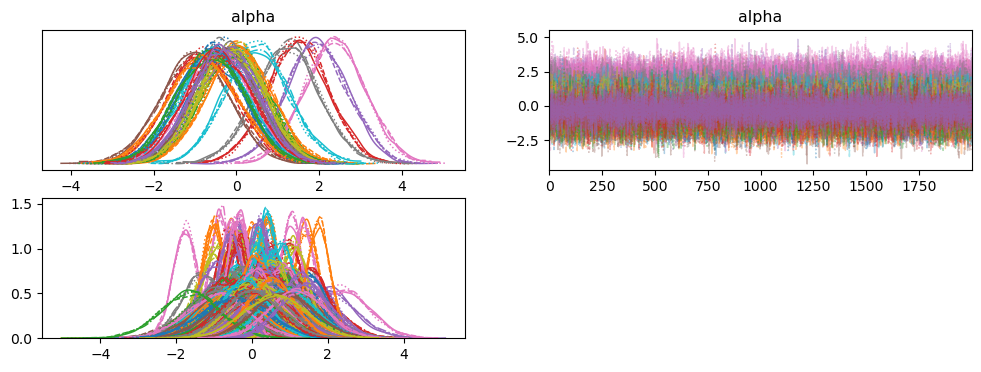

In [22]:
import arviz as az

az.summary(idata_final, var_names=["alpha", "beta"])
az.plot_trace(idata_final, var_names=["alpha", "beta"])

## FOR DISS

### Multinomial coefficient table

- **Rows** are predictors (including categorical levels).
- **Columns** are outcome classes.
- **`coef_sym`** gives posterior mean log-odds coefficients.
- **`or_sym`** gives exponentiated coefficients (odds ratios).

Because a sum-to-zero constraint is used:
- Coefficients represent *deviations from the average effect across outcome classes*.
- A **positive coefficient** means the predictor makes that class **more likely than average**.
- A **negative coefficient** means the predictor makes that class **less likely than average**.
- Odds ratios > 1 indicate increased odds of choosing that class; < 1 indicate decreased odds.

Each predictor has one coefficient per outcome class, because multinomial regression models 
the effect of predictors on each possible class. The sum-to-zero constraint removes the need 
for a baseline class and treats all outcome classes symmetrically.


### Pairwise results table

1. `feature`
The predictor whose effect is being evaluated.  
Examples:
- `Confidence` (numeric)  
- `trans_interact` (numeric)  
- `C(participant_gender_restrictive)[transgender]` (categorical level)

---

2. `class1`
The first identity category in the comparison.  
This is the category whose probability increases or decreases relative to `class2`.

---

3. `class2`
The second identity category in the comparison.  
Interpretation is always **class1 vs class2**.

---

4. `mean_log_odds_diff`

The posterior mean of the difference in log-odds:

$$
(\beta_{f,\text{class1}}) - (\beta_{f,\text{class2}})
$$


Interpretation:
- **Positive** → predictor increases odds of choosing **class1** over **class2**  
- **Negative** → predictor increases odds of choosing **class2** over **class1**

---

5. `hdi_log_odds_low`
6. `hdi_log_odds_high`

Lower and upper bounds of the **95% Highest Density Interval (HDI)** for the log-odds difference.

Interpretation:
- <span style="color:red"><b>If the interval does not cross 0, the effect is credibly different from zero.</b></span>
- Wide intervals indicate greater uncertainty

---

7. `mean_odds_ratio`

Exponentiated log-odds difference:

$$
\exp(\mathrm{mean\_log\_odds\_diff})
$$

Interpretation:
- **> 1** → predictor increases odds of choosing **class1**  
- **< 1** → predictor increases odds of choosing **class2**  
- Magnitude tells how strong the effect is

Example:  
`mean_odds_ratio = 9.9` → *“about 10× more likely to choose class1 over class2.”*

---

8. `hdi_or_low`  
9. `hdi_or_high`

The **95% credible interval** for the odds ratio.

Interpretation:
- If interval **does not include 1**, the direction of the effect is credible  
- Wide intervals indicate high uncertainty

---

Each row can be interpreted as:

> *“For predictor **feature**, the odds of labeling the speaker as **class1** rather than **class2** change by **mean_odds_ratio** (95% HDI: hdi_or_low–hdi_or_high).”*

A positive log-odds (and OR > 1) means the predictor pushes judgments toward **class1**;  
a negative log-odds (and OR < 1) means it pushes toward **class2**.

In [19]:
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt

# ============================================================
# 0) Basic setup: extract beta samples and feature metadata
# ============================================================

# Use the design matrix that matches idata_final
X_design = X_final  # <- IMPORTANT: no interactions model
if not isinstance(X_design, pd.DataFrame):
    # If it somehow isn't a DataFrame, coerce it
    feature_names = np.array(X_design.design_info.column_names)
    X_design = pd.DataFrame(np.asarray(X_design), columns=feature_names)
else:
    feature_names = np.array(X_design.columns)

# ---- Extract beta as (samples, features, classes) ----
beta_da = idata_final.posterior["beta"]   # <- use final model

# Rename dims if needed
if "feature" not in beta_da.dims or "class" not in beta_da.dims:
    # figure out the feature dim name
    dim_map = {}
    if "beta_dim_0" in beta_da.dims:
        dim_map["beta_dim_0"] = "feature"
    if "beta_dim_1" in beta_da.dims:
        dim_map["beta_dim_1"] = "class"
    beta_da = beta_da.rename(dim_map)

# Sanity check: feature dim length must match X_design columns
n_feat_posterior = beta_da.sizes["feature"]
n_feat_X = len(feature_names)
if n_feat_posterior != n_feat_X:
    raise ValueError(
        f"Feature mismatch: beta has {n_feat_posterior} features, "
        f"but X_design has {n_feat_X} columns. "
        f"Are you sure you're using the right design matrix?"
    )

beta_da = beta_da.assign_coords({
    "feature": feature_names,
    "class": classes,
})

# Stack chains/draws → (samples, features, classes)
beta_stack = beta_da.stack(sample=("chain", "draw"))
beta_vals = beta_stack.transpose("sample", "feature", "class").values
# beta_vals: (n_samples, n_features, n_classes)

n_samples, n_features, n_classes = beta_vals.shape
feature_names_arr = np.array(feature_names)
class_names = np.array(classes)

print("beta_vals shape:", beta_vals.shape)
print("n_features:", n_features)
print("first few features:", feature_names_arr[:5])

beta_vals shape: (8000, 48, 25)
n_features: 48
first few features: ['C(stimuli_clean, Sum)[mean]'
 'C(stimuli_clean, Sum)[S.breathy high (bottle)]'
 'C(stimuli_clean, Sum)[S.breathy high (said)]'
 'C(stimuli_clean, Sum)[S.breathy high (shed)]'
 'C(stimuli_clean, Sum)[S.breathy low (bottle)]']


In [20]:
import numpy as np
import pandas as pd
import arviz as az

def predictors_in_column(col: str) -> list[str]:
    """
    Given a design-matrix column name, return ALL predictor names
    that appear in it (main + interactions).

    Examples
    --------
    "Confidence"
        -> ["Confidence"]

    "C(stimuli_clean, Sum)[S.breathy high (bottle)]"
        -> ["stimuli_clean"]

    "C(stimuli_clean, Sum)[...]:C(race_ses_cond, Sum)[...]"
        -> ["stimuli_clean", "race_ses_cond"]
    """
    matches = re.findall(r"C\(([^,]+),\s*Sum\)", col)
    if matches:
        return [m.strip() for m in matches]
    else:
        # numeric or other non-C(...) column
        return [col]


# Build mapping: predictor -> list of feature indices (main + interaction)
pred_to_idx = {}
for j, col in enumerate(feature_names_arr):
    preds = predictors_in_column(col)
    for p in preds:
        pred_to_idx.setdefault(p, []).append(j)

# Unique predictor names (for ordering / plotting)
predictors = np.array(sorted(pred_to_idx.keys()))

def overall_regression_summary(
    beta_vals,
    pred_to_idx,
    rope=0.2,
    hdi_prob=0.95,
):
    """
    Overall summary per predictor using posterior mean and standard error
    of the global log-odds magnitude.

    For each predictor:
      - mean_log_mag: posterior mean of global |β| magnitude
      - se_log_mag  : posterior standard error of that magnitude
      - hdi_log_low/high: HDI of the magnitude on log scale
      - mean_or, hdi_or_*: same on OR scale (exp of magnitude)
      - pd_effect   : P(magnitude > rope)

    Interaction columns are INCLUDED: each predictor's set of columns
    consists of:
      - its main-effect levels
      - all interaction columns where it appears.
    """
    n_samples, n_features, n_classes = beta_vals.shape
    
    rows = []
    for pred, idx in pred_to_idx.items():
        idx = sorted(set(idx))
        # posterior samples for this predictor (samples × levels × classes)
        pred_samples = beta_vals[:, idx, :] 
        
        # global magnitude per sample:
        #   sqrt(sum of squares of all coefficients over levels & classes)
        mag = np.sqrt((pred_samples ** 2).sum(axis=(1, 2)))  # (samples,)

        # OR magnitude (exp of magnitude)
        or_mag = np.exp(mag)

        # HDI on log-magnitude
        hdi_log = az.hdi(mag, hdi_prob=hdi_prob)
        hdi_or  = np.exp(hdi_log)

        # posterior SE = sd / sqrt(n_samples)
        se_log = mag.std(ddof=1) / np.sqrt(n_samples)
        se_or  = or_mag.std(ddof=1) / np.sqrt(n_samples)

        # PD: probability magnitude > rope (practical relevance threshold)
        pd_eff = (mag > rope).mean()

        rows.append({
            "predictor": pred,
            "mean_log_mag": mag.mean(),
            "se_log_mag": se_log,
            "hdi_log_low": float(hdi_log[0]),
            "hdi_log_high": float(hdi_log[1]),
            "mean_or": or_mag.mean(),
            "se_or": se_or,
            "hdi_or_low": float(hdi_or[0]),
            "hdi_or_high": float(hdi_or[1]),
            "pd_effect": pd_eff,
        })
    
    df = (
        pd.DataFrame(rows)
        .sort_values("mean_log_mag", ascending=False)
        .reset_index(drop=True)
    )
    return df

overall_summary_df = overall_regression_summary(
    beta_vals=beta_vals,
    pred_to_idx=pred_to_idx,
    rope=0.2,        # practical threshold (log-odds)
    hdi_prob=0.90,
)

print("=== Overall Regression Summary Per Predictor (mean + SE) ===")
display(overall_summary_df)

=== Overall Regression Summary Per Predictor (mean + SE) ===


,predictor,mean_log_mag,se_log_mag,hdi_log_low,hdi_log_high,mean_or,se_or,hdi_or_low,hdi_or_high,pd_effect
0,stimuli_clean,17.346871,0.007059,16.343678,18.409461,4.177535e+07,332368.459188,1.253053e+07,9.888430e+07,1.0
1,race_ses_cond,12.574846,0.007192,11.471824,13.590628,3.552056e+05,2793.621967,9.597318e+04,7.986100e+05,1.0
2,participant_gender_restrictive,12.181710,0.007371,11.060682,13.227865,2.431788e+05,2040.315595,6.361990e+04,5.556342e+05,1.0
3,participant_sexuality_normed,11.526687,0.007420,10.401839,12.565484,1.263158e+05,1044.871545,3.292010e+04,2.864972e+05,1.0
4,participant_place_origin_normed,10.866380,0.007577,9.737387,11.965752,6.625215e+04,587.624777,1.693922e+04,1.572752e+05,1.0
5,participant_ses_normed,5.328804,0.006461,4.395614,6.274542,2.448279e+02,1.821064,8.109437e+01,5.308834e+02,1.0
6,sexuality_rep,3.320324,0.005104,2.512015,4.012920,3.078620e+01,0.172625,1.232975e+01,5.530816e+01,1.0
7,trans_interact,3.145947,0.004724,2.423547,3.814813,2.546011e+01,0.130170,1.128582e+01,4.536825e+01,1.0
8,community_rep,3.010613,0.004689,2.340775,3.722029,2.221157e+01,0.113256,1.038929e+01,4.134821e+01,1.0
9,Confidence,2.764501,0.003919,2.207886,3.361553,1.690576e+01,0.071396,9.096463e+00,2.883395e+01,1.0


In [21]:
overall_summary_df.columns

Index(['predictor', 'mean_log_mag', 'se_log_mag', 'hdi_log_low',
       'hdi_log_high', 'mean_or', 'se_or', 'hdi_or_low', 'hdi_or_high',
       'pd_effect'],
      dtype='object')

In [22]:
import re

def predictors_in_column(col: str) -> list[str]:
    """
    Return all predictor names that appear in a design column name.

    Examples
    --------
    "Confidence" -> ["Confidence"]
    "C(stimuli_clean, Sum)[S.breathy high]" -> ["stimuli_clean"]
    "C(stimuli_clean, Sum)[...]:C(race_ses_cond, Sum)[...]"
        -> ["stimuli_clean", "race_ses_cond"]
    """
    matches = re.findall(r"C\(([^,]+),\s*Sum\)", col)
    if matches:
        return [m.strip() for m in matches]
    else:
        return [col]


# Assuming feature_names_arr already exists (from your X_train / beta setup)
interaction_to_idx = {}

for j, col in enumerate(feature_names_arr):
    preds = sorted(set(predictors_in_column(col)))
    if len(preds) > 1:
        # Label interaction by predictors involved, e.g. "stimuli_clean × race_ses_cond"
        label = " × ".join(preds)
        interaction_to_idx.setdefault(label, []).append(j)

def interaction_regression_summary(
    beta_vals,
    interaction_to_idx,
    rope=0.2,
    hdi_prob=0.90,
):
    """
    Overall summary per interaction group using posterior mean and SE
    of the global log-odds magnitude, *only over interaction columns*.

    Returns a DataFrame with the SAME columns as overall_summary_df:
      predictor, mean_log_mag, se_log_mag,
      hdi_log_low, hdi_log_high,
      mean_or, se_or, hdi_or_low, hdi_or_high, pd_effect
    where 'predictor' is an interaction label like:
      'stimuli_clean × race_ses_cond'
    """
    import arviz as az
    n_samples, n_features, n_classes = beta_vals.shape
    
    rows = []
    for label, idx in interaction_to_idx.items():
        idx = sorted(set(idx))
        pred_samples = beta_vals[:, idx, :]  # (samples, interaction_cols, classes)

        # global magnitude per sample
        mag = np.sqrt((pred_samples ** 2).sum(axis=(1, 2)))  # (samples,)

        or_mag = np.exp(mag)

        hdi_log = az.hdi(mag, hdi_prob=hdi_prob)
        hdi_or  = np.exp(hdi_log)

        se_log = mag.std(ddof=1) / np.sqrt(n_samples)
        se_or  = or_mag.std(ddof=1) / np.sqrt(n_samples)

        pd_eff = (mag > rope).mean()

        rows.append({
            "predictor":   label,
            "mean_log_mag": mag.mean(),
            "se_log_mag":   se_log,
            "hdi_log_low":  float(hdi_log[0]),
            "hdi_log_high": float(hdi_log[1]),
            "mean_or":      or_mag.mean(),
            "se_or":        se_or,
            "hdi_or_low":   float(hdi_or[0]),
            "hdi_or_high":  float(hdi_or[1]),
            "pd_effect":    pd_eff,
        })
    
    df = (
        pd.DataFrame(rows)
        .sort_values("mean_log_mag", ascending=False)
        .reset_index(drop=True)
    )
    return df

# Build interaction-only summary
interaction_summary_df = interaction_regression_summary(
    beta_vals=beta_vals,
    interaction_to_idx=interaction_to_idx,
    rope=0.2,
    hdi_prob=0.90,
)

KeyError: 'mean_log_mag'

In [23]:
import numpy as np
import pandas as pd

# Make sure X_train is a DataFrame with correct columns
if not isinstance(X_train, pd.DataFrame):
    feature_names = np.array(X_train.design_info.column_names)
    X_train = pd.DataFrame(np.asarray(X_train), columns=feature_names)

# Make X_val a DataFrame with the SAME columns as X_train
if not isinstance(X_val, pd.DataFrame):
    X_val = pd.DataFrame(np.asarray(X_val), columns=X_train.columns)

# Now this will work:
X_val_final = build_design_with_interactions(
    X_full=X_val,
    main_cols=main_cols,
    interaction_blocks=interaction_blocks,
    active_interactions=active_interactions,  # [] for final model
)

X_val_array = X_val_final.values.astype(float)

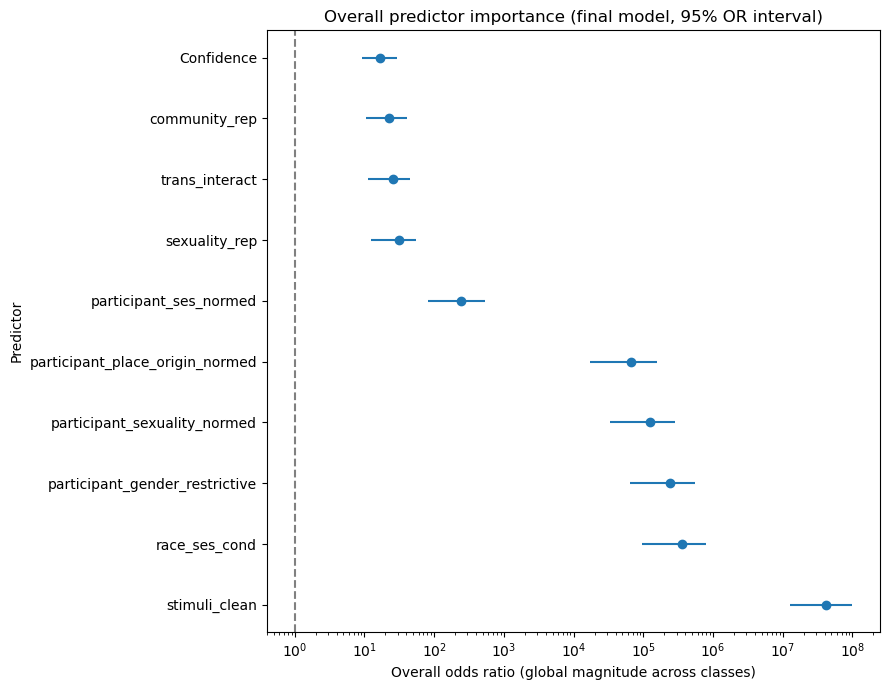

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Forest plot: overall predictor importance (final model)
# ============================================================

forest_df = overall_summary_df.copy()
forest_df["kind"] = "main effects"

# Sort by mean OR for plotting (descending)
forest_df = (
    forest_df
    .sort_values("mean_or", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(9, 0.5 * len(forest_df) + 2))

or_vals = forest_df["mean_or"].values
or_low  = forest_df["hdi_or_low"].values   # 95% HDI on OR scale
or_high = forest_df["hdi_or_high"].values

err_low  = or_vals - or_low
err_high = or_high - or_vals

y_pos = np.arange(len(forest_df))

plt.errorbar(
    or_vals,
    y_pos,
    xerr=[err_low, err_high],
    fmt="o",
    linestyle="none",
)

plt.yticks(y_pos, forest_df["predictor"])
plt.axvline(1.0, linestyle="--", color="gray")  # OR=1 reference
plt.xscale("log")
plt.xlabel("Overall odds ratio (global magnitude across classes)")
plt.ylabel("Predictor")
plt.title("Overall predictor importance (final model, 95% OR interval)")
plt.tight_layout()
plt.show()

alpha_da.dims: ('chain', 'draw', 'alpha_dim_0')
beta_da.dims: ('chain', 'draw', 'beta_dim_0', 'beta_dim_1')
speaker_re_da.dims: ('chain', 'draw', 'speaker_re_dim_0', 'speaker_re_dim_1')
Posterior samples S, features F, classes K: 8000 48 25


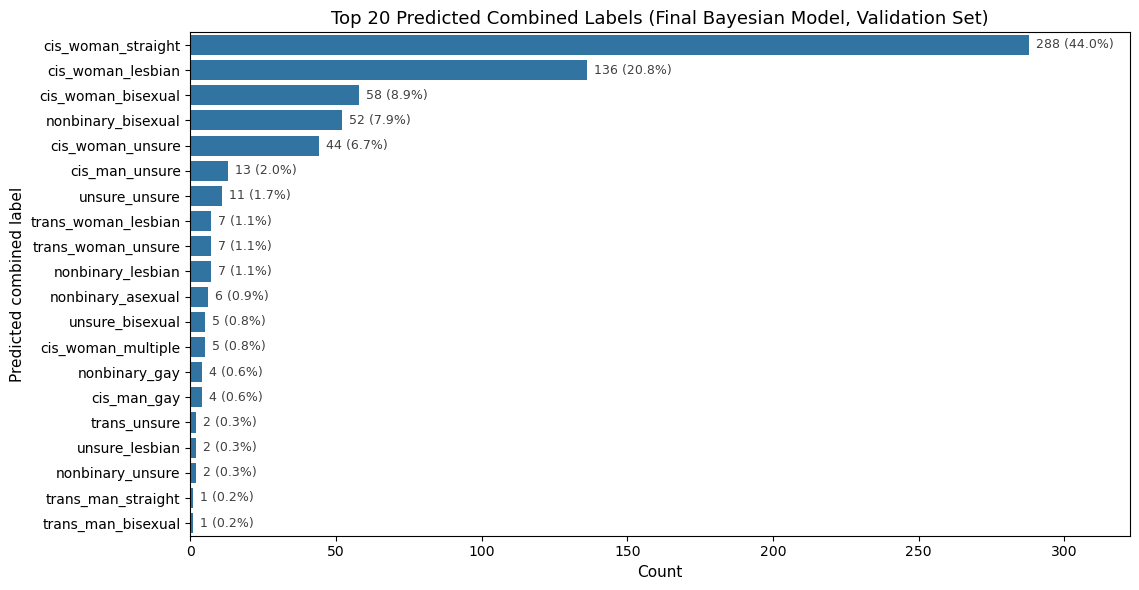

In [25]:
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 5) Frequency plot of top-20 predicted classes (validation set)
#    using FINAL model (no interactions)
# ============================================================

# 0) Make sure X_train / X_val are DataFrames with consistent columns
if not isinstance(X_train, pd.DataFrame):
    feature_names = np.array(X_train.design_info.column_names)
    X_train_df = pd.DataFrame(np.asarray(X_train), columns=feature_names)
else:
    X_train_df = X_train.copy()
    feature_names = X_train_df.columns.to_numpy()

if not isinstance(X_val, pd.DataFrame):
    X_val_df = pd.DataFrame(np.asarray(X_val), columns=feature_names)
else:
    X_val_df = X_val.copy()

# 1) Build validation design matrix matching the FINAL model
X_val_final = build_design_with_interactions(
    X_full=X_val_df,
    main_cols=main_cols,
    interaction_blocks=interaction_blocks,
    active_interactions=active_interactions,  # [] for final model
)

X_val_array = X_val_final.values.astype(float)
n_val = X_val_array.shape[0]

# speaker_val: codes for each validation observation
speaker_val = df_val["speaker_code"].to_numpy().astype(int)

# 2) Extract posterior draws from FINAL model

# --- alpha ---
alpha_da = idata_final.posterior["alpha"]
print("alpha_da.dims:", alpha_da.dims)

if "class" not in alpha_da.dims:
    last_dim = alpha_da.dims[-1]
    alpha_da = alpha_da.rename({last_dim: "class"})

alpha = (
    alpha_da
    .stack(sample=("chain", "draw"))
    .transpose("sample", "class")
    .values
)  # (S, K)

# --- beta ---
beta_da = idata_final.posterior["beta"]
print("beta_da.dims:", beta_da.dims)

dim_map = {}
if "beta_dim_0" in beta_da.dims:
    dim_map["beta_dim_0"] = "feature"
if "beta_dim_1" in beta_da.dims:
    dim_map["beta_dim_1"] = "class"
beta_da = beta_da.rename(dim_map)

beta = (
    beta_da
    .stack(sample=("chain", "draw"))
    .transpose("sample", "feature", "class")
    .values
)  # (S, F, K)

# --- speaker_re ---
speaker_re_da = idata_final.posterior["speaker_re"]
print("speaker_re_da.dims:", speaker_re_da.dims)

dim_map_re = {}
for d in speaker_re_da.dims:
    if "speaker" in d and d != "speaker":
        dim_map_re[d] = "speaker"
if ("class" not in speaker_re_da.dims) and ("speaker_re_dim_1" in speaker_re_da.dims):
    dim_map_re["speaker_re_dim_1"] = "class"

speaker_re_da = speaker_re_da.rename(dim_map_re)

speaker_re = (
    speaker_re_da
    .stack(sample=("chain", "draw"))
    .transpose("sample", "speaker", "class")
    .values
)  # (S, n_speakers, K)

S, F, K = beta.shape
print("Posterior samples S, features F, classes K:", S, F, K)

# 3) Compute posterior predictive p(y | x) on validation set

# X_val_array: (N, F), beta: (S, F, K) -> (S, N, K)
lin = np.einsum("nf,sfk->snk", X_val_array, beta)

# speaker_re[:, speaker_val, :] -> (S, N, K)
spk = speaker_re[:, speaker_val, :]

eta = alpha[:, None, :] + spk + lin   # (S, N, K)

# Softmax over classes
eta_max = eta.max(axis=-1, keepdims=True)
p = np.exp(eta - eta_max)
p /= p.sum(axis=-1, keepdims=True)    # (S, N, K)

# Posterior mean probability for each observation and class
p_val_mean = p.mean(axis=0)           # (N, K)

# --- NEW: compute y_val_pred from p_val_mean ---
y_val_pred_idx = p_val_mean.argmax(axis=1)
y_val_pred = np.array(classes)[y_val_pred_idx]

# 4) Predicted classes and top-20 frequency plot (styled like the RF plot)

pred_counts = (
    pd.Series(y_val_pred)
      .value_counts()
      .sort_values(ascending=False)
)

top_k = 20
top = pred_counts.head(top_k)

df_freq = (
    top
    .reset_index()
    .rename(columns={"index": "identity", 0: "count"})
)

plt.figure(figsize=(11.5, 6))
single_color = sns.color_palette("tab20")[0]

ax = sns.barplot(
    x="count",
    y="identity",
    data=df_freq,
    orient="h",
    color=single_color,
)

ax.set_xlim(0, df_freq["count"].max() * 1.12)

total = df_freq["count"].sum()
for p_patch in ax.patches:
    w = p_patch.get_width()
    y = p_patch.get_y() + p_patch.get_height() / 2
    pct = (w / total * 100.0) if total else 0.0
    ax.annotate(
        f"{int(w)} ({pct:.1f}%)",
        xy=(w, y),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
        ha="left",
        fontsize=9,
        color="0.25",
    )

ax.set_xlabel("Count", fontsize=11)
ax.set_ylabel("Predicted combined label", fontsize=11)
ax.set_title("Top 20 Predicted Combined Labels (Final Bayesian Model, Validation Set)",
             fontsize=13)

plt.tight_layout()
plt.show()

In [26]:
val_pred_df = df_val.copy()
val_pred_df["pred_class"] = y_val_pred

Top-2 predicted labels (Bayesian final model): ['cis_woman_straight', 'cis_woman_lesbian']


/var/folders/_p/8f1m1pq55m96ch4vpbjsm5zh0000gn/T/ipykernel_15514/1436610752.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['stimuli_clean', 'source'])
/var/folders/_p/8f1m1pq55m96ch4vpbjsm5zh0000gn/T/ipykernel_15514/1436610752.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['stimuli_clean', label_col, 'source'])
/var/folders/_p/8f1m1pq55m96ch4vpbjsm5zh0000gn/T/ipykernel_15514/1436610752.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to ado

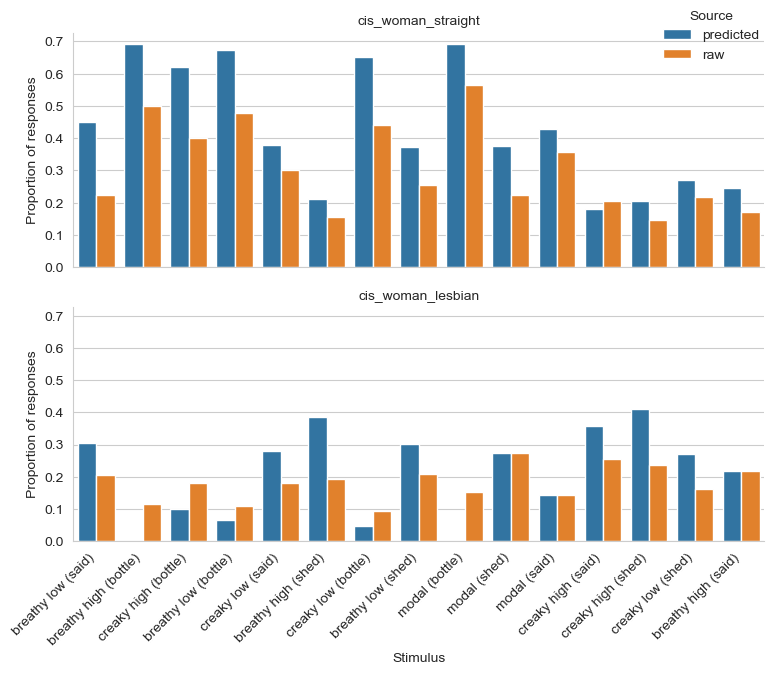

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# 0. Use validation indices + Bayesian predictions
# -----------------------------------------------------------
label_col = "identity"          # or "combined" if you have a separate Bayesian model
idx = df_val.index             # validation rows (same order as y_val_pred)

# Raw labels on validation indices
df_raw = df.loc[idx, ['stimuli_clean', label_col]].copy()
df_raw['source'] = 'raw'

# Predicted labels on the same rows from the FINAL Bayesian model
df_pred = df_val.loc[idx, ['stimuli_clean']].copy()
df_pred[label_col] = y_val_pred      # <-- Bayesian predicted labels (from p_val_mean.argmax)
df_pred['source'] = 'predicted'

# Stack raw + predicted
df_all = pd.concat([df_raw, df_pred], ignore_index=True)

# -----------------------------------------------------------
# 1. Top-2 *predicted* labels under the Bayesian model
# -----------------------------------------------------------
top2_pred_labels = (
    df_pred[label_col]
    .value_counts()
    .head(2)
    .index
)

print("Top-2 predicted labels (Bayesian final model):", top2_pred_labels.tolist())

# -----------------------------------------------------------
# 2. Totals per stimulus × source (all labels)
# -----------------------------------------------------------
totals = (
    df_all
    .groupby(['stimuli_clean', 'source'])
    .size()
    .reset_index(name='total')
)

# -----------------------------------------------------------
# 3. Counts for top-2 labels only
# -----------------------------------------------------------
df_plot = (
    df_all[df_all[label_col].isin(top2_pred_labels)]
    .groupby(['stimuli_clean', label_col, 'source'])
    .size()
    .reset_index(name='count')
)

# Merge in totals so we can compute proportions
df_plot = df_plot.merge(
    totals,
    on=['stimuli_clean', 'source'],
    how='left'
)

df_plot['prop'] = df_plot['count'] / df_plot['total']

# -----------------------------------------------------------
# 4. Order stimuli by total *predicted* count (nicer plotting)
# -----------------------------------------------------------
stim_order = (
    df_plot[df_plot['source'] == 'predicted']
    .groupby('stimuli_clean')['count']
    .sum()
    .sort_values(ascending=False)
    .index
)

# -----------------------------------------------------------
# 5. Plot: ONE column, TWO rows (one row per top label), RF-style
# -----------------------------------------------------------
sns.set_style("whitegrid")

g = sns.catplot(
    data=df_plot,
    x='stimuli_clean',
    y='prop',
    hue='source',              # legend: raw vs predicted
    row=label_col,             # one row per label ("identity" or "combined")
    row_order=top2_pred_labels,
    kind='bar',
    order=stim_order,
    height=3.4,
    aspect=2.0,
    sharex=True,
    sharey=True,               # same y-scale across rows
)

# Titles: use the label name for each row
g.set_titles("{row_name}")

# Rotate x-ticks 45° on bottom row only
for ax in g.axes[-1]:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Legend: inside, upper-right (same style as before)
leg = g._legend
leg.set_title("Source")
leg.loc = "upper right"
leg.set_bbox_to_anchor((0.98, 0.94))

g.set_axis_labels("Stimulus", "Proportion of responses")
plt.tight_layout()
plt.show()

/var/folders/_p/8f1m1pq55m96ch4vpbjsm5zh0000gn/T/ipykernel_15514/1135534110.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub.groupby(["pred", group_col])


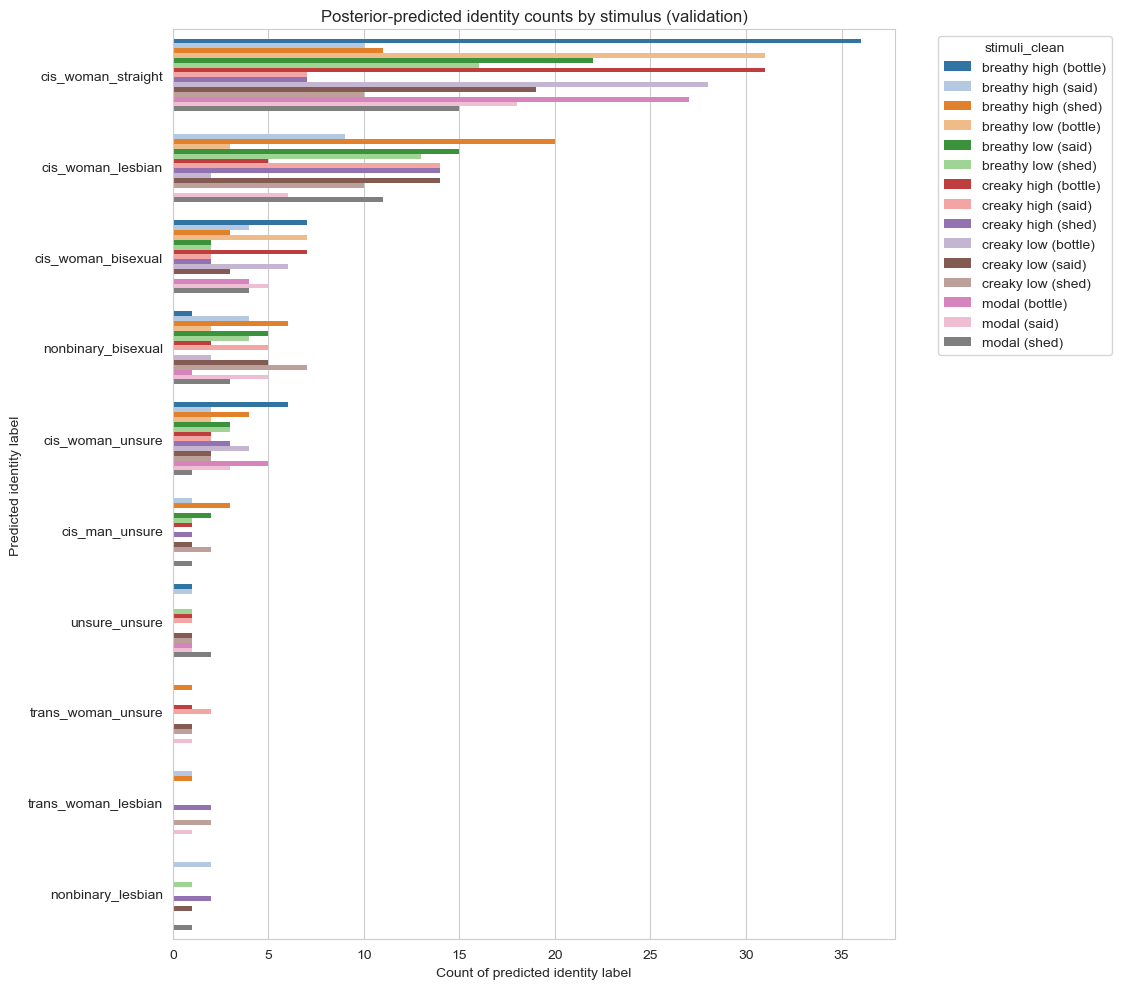

/var/folders/_p/8f1m1pq55m96ch4vpbjsm5zh0000gn/T/ipykernel_15514/1135534110.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub.groupby(["pred", group_col])


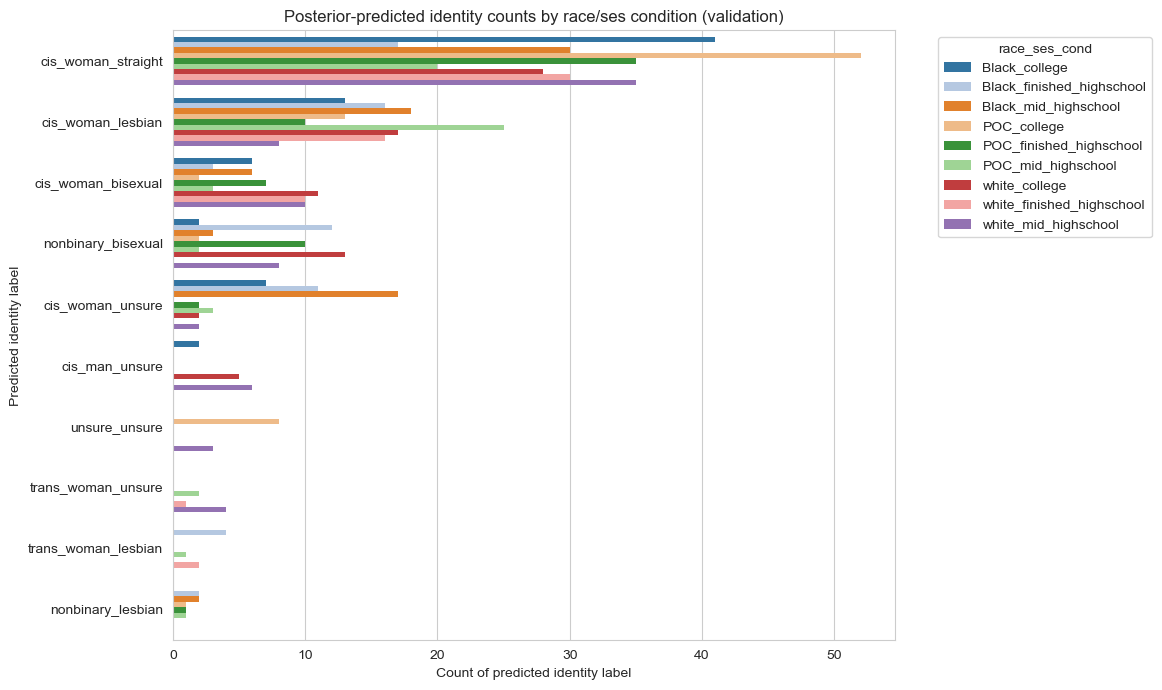

/var/folders/_p/8f1m1pq55m96ch4vpbjsm5zh0000gn/T/ipykernel_15514/1135534110.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub.groupby(["pred", group_col])


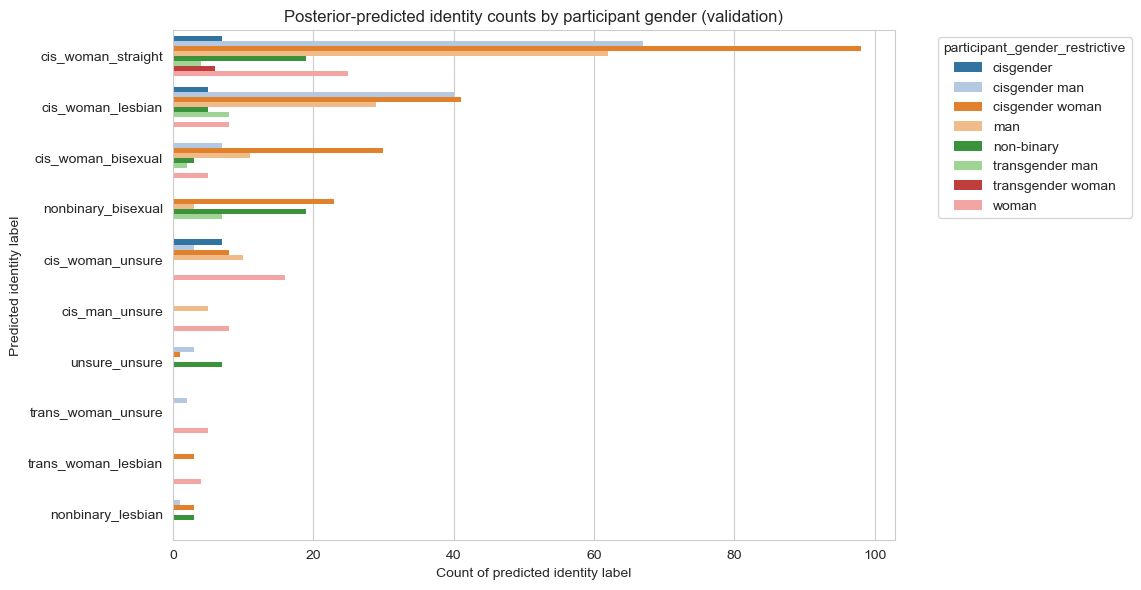

/var/folders/_p/8f1m1pq55m96ch4vpbjsm5zh0000gn/T/ipykernel_15514/1135534110.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub.groupby(["pred", group_col])


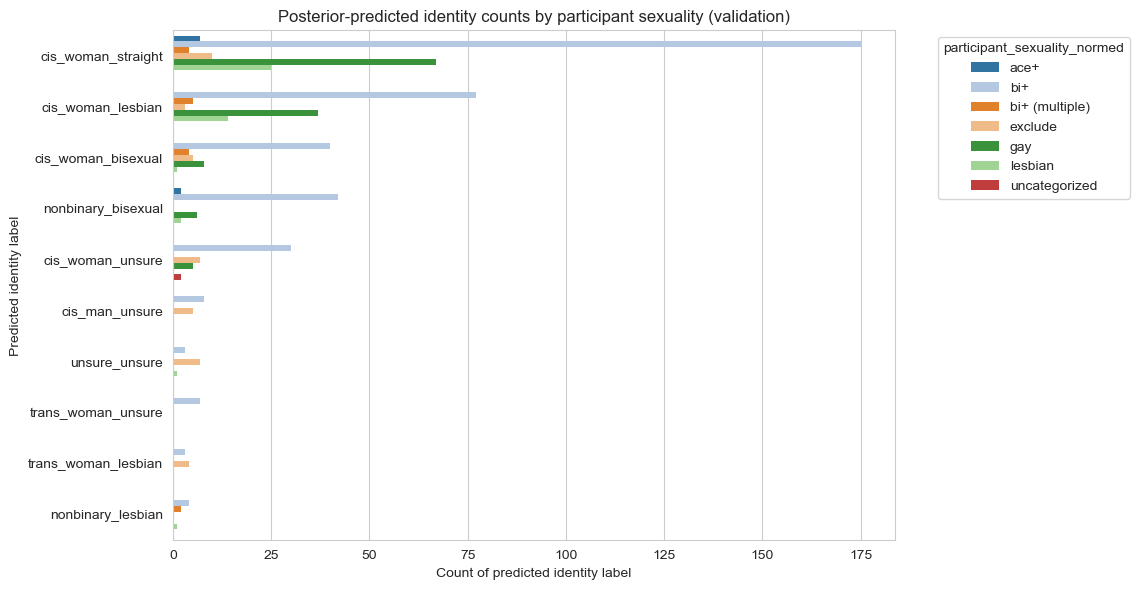

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1) Helper: counts by predicted class × group (for val_pred_df)
# ============================================================
def counts_by_group_val(df, group_col, *, pred_col="pred_class",
                        all_levels=None, class_order=None):
    """
    Return a tidy DataFrame of counts by predicted label × group.

    df        : DataFrame with columns [group_col, pred_col]
    group_col : predictor you want in the legend
    pred_col  : column with predicted class labels (default "pred_class")
    """
    sub = pd.DataFrame({
        group_col: df[group_col],
        "pred": df[pred_col],
    })

    counts = (
        sub.groupby(["pred", group_col])
           .size()
           .rename("count")
           .reset_index()
    )

    # If not supplied, infer from the data actually present
    if class_order is None:
        class_order = sorted(counts["pred"].unique().tolist())
    if all_levels is None:
        all_levels = sorted(sub[group_col].dropna().unique().tolist())

    # Full grid of pred × group (for consistency)
    mi = pd.MultiIndex.from_product([class_order, all_levels],
                                    names=["pred", group_col])
    counts_full = (
        counts.set_index(["pred", group_col])
              .reindex(mi, fill_value=0)
              .reset_index()
    )
    return counts_full, class_order, all_levels

# ============================================================
# 2) Barplot with SAME formatting as barplot_separate_tab20
#    but only non-empty predictors *and* non-empty classes
# ============================================================
def barplot_separate_tab20_val(
    df,                    # <- val_pred_df
    group_col,
    title,
    *,
    pred_col="pred_class",
    all_levels=None,
    class_order=None,
    figsize=(14, 8),
    top_n=None  # None = show ALL classes, or set an int to keep top N
):
    """
    Horizontal grouped barplot (tab20 palette), matching your original style:
    - y-axis: predicted class (sorted by frequency)
    - x-axis: counts
    - hue: levels of `group_col` (in legend)
    Only keeps:
      - predictor levels with ≥ 1 prediction
      - predicted classes with ≥ 1 prediction
    """

    tidy, class_order, all_levels = counts_by_group_val(
        df, group_col,
        pred_col=pred_col,
        all_levels=all_levels,
        class_order=class_order,
    )

    # --- Remove predictor levels that have zero total predictions ---
    level_counts = tidy.groupby(group_col)["count"].sum()
    valid_levels = level_counts[level_counts > 0].index.tolist()
    tidy = tidy[tidy[group_col].isin(valid_levels)]
    all_levels = valid_levels  # update ordering for palette + legend

    # --- Remove predicted classes that have zero total predictions (after level filtering) ---
    totals = tidy.groupby("pred")["count"].sum()
    valid_preds = totals[totals > 0].sort_values(ascending=False).index.tolist()
    tidy = tidy[tidy["pred"].isin(valid_preds)]
    class_order = valid_preds  # y-axis order: most frequent first

    # --- Optionally keep only top N predicted classes ---
    if top_n is not None and len(class_order) > top_n:
        class_order = class_order[:top_n]
        tidy = tidy[tidy["pred"].isin(class_order)]

    # --- Consistent color palette (tab20) keyed on group levels ---
    palette = dict(zip(
        all_levels,
        sns.color_palette("tab20", n_colors=len(all_levels))
    ))

    plt.figure(figsize=figsize)
    ax = sns.barplot(
        data=tidy,
        x="count",
        y="pred",          # predicted classes on y-axis
        hue=group_col,     # predictor levels in legend
        order=class_order,
        hue_order=all_levels,
        orient="h",
        palette=palette,
        edgecolor="none",
    )

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Count of predicted identity label")
    ax.set_ylabel("Predicted identity label")

    ax.legend(title=group_col, bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.subplots_adjust(right=0.75)
    plt.show()


# ============================================================
# 3) Example calls using val_pred_df
# ============================================================

# interactions
# val_pred_df["stimuli_x_race"] = (
#     val_pred_df["stimuli_clean"].astype(str)
#     + " | "
#     + val_pred_df["race_ses_cond"].astype(str)
# )

# categorical predictors: use the original columns in df_val / val_pred_df
barplot_separate_tab20_val(
    val_pred_df,
    group_col="stimuli_clean",
    title="Posterior-predicted identity counts by stimulus (validation)",
    class_order=classes,          # same global class ordering if you want
    figsize=(12, 10),
    top_n=10                    # None = show ALL predicted classes
)

barplot_separate_tab20_val(
    val_pred_df,
    group_col="race_ses_cond",
    title="Posterior-predicted identity counts by race/ses condition (validation)",
    class_order=classes,
    figsize=(12, 7),
    top_n=10
)

barplot_separate_tab20_val(
    val_pred_df,
    group_col="participant_gender_restrictive",
    title="Posterior-predicted identity counts by participant gender (validation)",
    class_order=classes,
    figsize=(12, 6),
    top_n=10
)

barplot_separate_tab20_val(
    val_pred_df,
    group_col="participant_sexuality_normed",
    title="Posterior-predicted identity counts by participant sexuality (validation)",
    class_order=classes,
    figsize=(12, 6),
    top_n=10,
)


In [29]:
import numpy as np
import pandas as pd
import arviz as az
import itertools

# ------------------------------------------------------------
# 0) PD helper (same as before)
# ------------------------------------------------------------
def prob_of_direction(samples_1d: np.ndarray) -> float:
    """
    Probability of Direction (PD):
    max( P(effect > 0), P(effect < 0) ).
    """
    return max((samples_1d > 0).mean(), (samples_1d < 0).mean())


# ------------------------------------------------------------
# 1) Find design columns + coding vectors per level for a predictor
# ------------------------------------------------------------
def get_coding_for_predictor(
    feature_names_arr: np.ndarray,
    X_design: pd.DataFrame,
    df_train: pd.DataFrame,
    predictor: str,
):
    """
    For a categorical predictor (e.g. 'stimuli_clean'), find:

      - dummy_idx: indices of columns in the design matrix corresponding
                   to this predictor (works for C(pred) and C(pred, Sum))
      - level_names: list of *actual* level names (from df_train[predictor])
      - codes: array of shape (n_levels, n_dummy_cols) giving the contrast
               coding for each level on those columns.

    This works for both treatment coding and sum coding because we get the
    coding directly from X_design rows corresponding to each level.
    """
    # Any column that looks like it came from C(predictor, ...) or C(predictor)
    # will contain 'C(predictor' and a '['
    search = f"C({predictor}"
    dummy_idx = [
        i
        for i, name in enumerate(feature_names_arr)
        if (search in name) and ("[" in name)
    ]

    if not dummy_idx:
        raise ValueError(f"No design-matrix columns found for predictor {predictor!r}")

    dummy_idx = np.array(dummy_idx, dtype=int)
    dummy_cols = [feature_names_arr[i] for i in dummy_idx]

    # Get the actual levels from df_train
    # (use categories if it's a Categorical, else unique values)
    col = df_train[predictor]
    if hasattr(col, "cat"):
        level_names = list(col.cat.categories)
    else:
        level_names = sorted(col.dropna().unique().tolist())

    # For each level, find a row in df_train with that level, and read off
    # the coding pattern in X_design[dummy_cols].
    codes = []
    for lvl in level_names:
        mask = (df_train[predictor] == lvl)
        idx_candidates = df_train.index[mask]

        if len(idx_candidates) == 0:
            # level present in categories but not actually used in train
            # give it a zero-vector coding (unlikely but safe)
            codes.append(np.zeros(len(dummy_cols)))
            continue

        # Use the first row with that level
        row_idx = idx_candidates[0]
        # We assume X_design has the same index as df_train (patsy does this)
        row_vals = X_design.loc[row_idx, dummy_cols].to_numpy(dtype=float)
        codes.append(row_vals)

    codes = np.vstack(codes)  # (n_levels, n_dummy_cols)
    return dummy_idx, level_names, codes


# ------------------------------------------------------------
# 2) Level-wise pairwise contrasts for one predictor
# ------------------------------------------------------------
def level_pairwise_contrasts_for_predictor(
    beta_vals: np.ndarray,
    feature_names_arr: np.ndarray,
    class_names,
    predictor: str,
    X_design: pd.DataFrame,
    df_train: pd.DataFrame,
    hdi_prob: float = 0.90,
):
    """
    For a given categorical predictor:
      - reconstruct its level-wise coefficients (via coding vectors)
      - compute pairwise contrasts between levels for each class

    Returns a DataFrame with columns:
      predictor, level1, level2, class
      mean_log_odds_diff, hdi_log_low, hdi_log_high
      mean_or, hdi_or_low, hdi_or_high
      pd, credible, or_strength, abs_log_diff
    """
    n_samples, n_features, n_classes = beta_vals.shape

    dummy_idx, level_names, codes = get_coding_for_predictor(
        feature_names_arr=feature_names_arr,
        X_design=X_design,
        df_train=df_train,
        predictor=predictor,
    )

    # beta for this predictor's design columns
    # shape: (samples, n_dummy_cols, classes)
    beta_sub = beta_vals[:, dummy_idx, :]

    # codes: (n_levels, n_dummy_cols)
    # We want level-specific effects: (samples, levels, classes)
    # effect[s, l, k] = sum_j codes[l, j] * beta_sub[s, j, k]
    effects = np.einsum("sdk,ld->slk", beta_sub, codes)

    n_levels = len(level_names)
    lower_q = (1 - hdi_prob) / 2
    upper_q = 1 - lower_q

    records = []

    # All unique level pairs (l1 < l2)
    for a_idx, b_idx in itertools.combinations(range(n_levels), 2):
        lvl_a = level_names[a_idx]
        lvl_b = level_names[b_idx]

        # samples × classes differences
        diff = effects[:, a_idx, :] - effects[:, b_idx, :]  # (samples, classes)

        for k, class_label in enumerate(class_names):
            s_1d = diff[:, k]

            mean_log = s_1d.mean()
            lo_log   = np.quantile(s_1d, lower_q)
            hi_log   = np.quantile(s_1d, upper_q)

            mean_or = np.exp(mean_log)
            lo_or   = np.exp(lo_log)
            hi_or   = np.exp(hi_log)

            credible = not (lo_log < 0 < hi_log)
            pd_val = prob_of_direction(s_1d)

            records.append({
                "predictor": predictor,
                "level1": lvl_a,
                "level2": lvl_b,
                "class": class_label,
                "mean_log_odds_diff": mean_log,
                "hdi_log_low": lo_log,
                "hdi_log_high": hi_log,
                "mean_or": mean_or,
                "hdi_or_low": lo_or,
                "hdi_or_high": hi_or,
                "pd": pd_val,
                "credible": credible,
            })

    df = pd.DataFrame.from_records(records)

    # Symmetric effect-size measure: distance of OR from 1
    or_vals = df["mean_or"].to_numpy()
    df["abs_log_diff"] = df["mean_log_odds_diff"].abs()
    df["or_strength"]  = np.exp(df["abs_log_diff"])
    return df


# ------------------------------------------------------------
# 3) All categorical predictors
# ------------------------------------------------------------
def all_categorical_level_pairs(
    beta_vals: np.ndarray,
    feature_names_arr: np.ndarray,
    class_names,
    predictors,
    X_design: pd.DataFrame,
    df_train: pd.DataFrame,
    hdi_prob: float = 0.90,
):
    """
    Compute level-wise pairwise contrasts for a list of categorical predictors
    and concatenate into one big DataFrame.
    """
    all_dfs = []
    for pred in predictors:
        df_pred = level_pairwise_contrasts_for_predictor(
            beta_vals=beta_vals,
            feature_names_arr=feature_names_arr,
            class_names=class_names,
            predictor=pred,
            X_design=X_design,
            df_train=df_train,
            hdi_prob=hdi_prob,
        )
        all_dfs.append(df_pred)
    return pd.concat(all_dfs, ignore_index=True)

### Single effects

In [30]:
cat_predictors = [
    "stimuli_clean",
    "race_ses_cond",
    "participant_gender_restrictive",
    "participant_sexuality_normed",
    "participant_place_origin_normed",
    "participant_ses_normed",
]

pairs_all = all_categorical_level_pairs(
    beta_vals=beta_vals,
    feature_names_arr=feature_names_arr,   # np.array(X_train.columns)
    class_names=class_names,               # np.array(classes)
    predictors=cat_predictors,
    X_design=X_train,                      # patsy design DataFrame
    df_train=df_train,                     # original training DF
    hdi_prob=0.90,
)

print(len(pairs_all), "rows total")
pairs_all.head()

5350 rows total


,predictor,level1,level2,class,mean_log_odds_diff,hdi_log_low,hdi_log_high,mean_or,hdi_or_low,hdi_or_high,pd,credible,abs_log_diff,or_strength
0,stimuli_clean,breathy high (bottle),breathy high (said),cis_man_gay,-1.458854,-3.246440,0.314818,0.232503,0.038912,1.370010,0.913375,False,1.458854,4.301027
1,stimuli_clean,breathy high (bottle),breathy high (said),cis_man_unsure,0.579010,-1.118505,2.260340,1.784271,0.326768,9.586351,0.714500,False,0.579010,1.784271
2,stimuli_clean,breathy high (bottle),breathy high (said),cis_woman_asexual,0.897470,-0.920962,2.706006,2.453389,0.398136,14.969374,0.795625,False,0.897470,2.453389
3,stimuli_clean,breathy high (bottle),breathy high (said),cis_woman_bisexual,1.363812,0.505070,2.227287,3.911075,1.657102,9.274672,0.995000,True,1.363812,3.911075
4,stimuli_clean,breathy high (bottle),breathy high (said),cis_woman_lesbian,0.178317,-0.709241,1.046288,1.195204,0.492017,2.847064,0.632750,False,0.178317,1.195204


In [31]:
pd_min = 0.90
or_cap = 1e3  # max allowed upper HDI bound

pairs_sig = (
    pairs_all
    .query(
        "credible and pd >= @pd_min and hdi_or_high <= @or_cap"
    )
    .sort_values("or_strength", ascending=False)
    .reset_index(drop=True)
)
print("Significant contrasts (credible & PD >= 0.90):")
print(len(pairs_sig))
display(pairs_sig.head(50).sort_values("hdi_or_high", ascending=False))

Significant contrasts (credible & PD >= 0.90):
295


,predictor,level1,level2,class,mean_log_odds_diff,hdi_log_low,hdi_log_high,mean_or,hdi_or_low,hdi_or_high,pd,credible,abs_log_diff,or_strength
19,participant_gender_restrictive,man,woman,nonbinary_bisexual,2.999354,0.043516,6.448256,20.072567,1.044476,631.600116,0.951875,True,2.999354,20.072567
5,participant_place_origin_normed,South/Midwestern US,USA (general),cis_woman_unsure,3.614726,1.665731,5.551375,37.141159,5.289537,257.591569,0.999375,True,3.614726,37.141159
9,participant_place_origin_normed,(East) Asia,USA (general),cis_woman_unsure,3.313026,1.445520,5.185729,27.468118,4.244057,178.703697,0.999125,True,3.313026,27.468118
23,participant_ses_normed,high_income,middle_income,trans_man_bisexual,2.840714,0.504337,5.151636,17.127999,1.655887,172.713836,0.976000,True,2.840714,17.127999
43,stimuli_clean,creaky high (shed),modal (shed),trans_woman_lesbian,2.376935,0.352497,4.756098,10.771835,1.422615,116.291271,0.976500,True,2.376935,10.771835
37,participant_place_origin_normed,Africa/uncategorized,USA (general),trans_man_gay,2.462039,0.329937,4.692146,11.728707,1.390881,109.086987,0.973625,True,2.462039,11.728707
26,participant_place_origin_normed,Europe,USA (general),cis_woman_unsure,2.759976,1.073191,4.470960,15.799465,2.924696,87.440592,0.996750,True,2.759976,15.799465
31,participant_place_origin_normed,Africa/uncategorized,USA (general),cis_woman_unsure,2.598520,0.765133,4.431059,13.443829,2.149280,84.020351,0.990000,True,2.598520,13.443829
12,stimuli_clean,breathy high (bottle),creaky high (said),cis_woman_straight,3.213776,2.454191,3.993204,24.872833,11.637019,54.228362,1.000000,True,3.213776,24.872833
16,stimuli_clean,breathy low (bottle),creaky high (said),cis_woman_straight,3.140477,2.380973,3.919142,23.114898,10.815424,50.357205,1.000000,True,3.140477,23.114898


In [32]:
stimuli_sig = (
    pairs_sig
    .query("predictor == 'stimuli_clean'")
    .sort_values("or_strength", ascending=False)
)

print(len(stimuli_sig))
display(stimuli_sig.head(10))

237


,predictor,level1,level2,class,mean_log_odds_diff,hdi_log_low,hdi_log_high,mean_or,hdi_or_low,hdi_or_high,pd,credible,abs_log_diff,or_strength
6,stimuli_clean,creaky high (said),modal (bottle),cis_woman_straight,-3.519922,-4.304457,-2.745011,0.029602,0.013508,0.064248,1.000000,True,3.519922,33.781782
12,stimuli_clean,breathy high (bottle),creaky high (said),cis_woman_straight,3.213776,2.454191,3.993204,24.872833,11.637019,54.228362,1.000000,True,3.213776,24.872833
16,stimuli_clean,breathy low (bottle),creaky high (said),cis_woman_straight,3.140477,2.380973,3.919142,23.114898,10.815424,50.357205,1.000000,True,3.140477,23.114898
20,stimuli_clean,creaky low (said),modal (shed),unsure_unsure,-2.948095,-4.940963,-0.953664,0.052439,0.007148,0.385327,0.990875,True,2.948095,19.069596
24,stimuli_clean,creaky high (said),creaky low (bottle),cis_woman_straight,-2.804572,-3.550257,-2.065060,0.060533,0.028717,0.126811,1.000000,True,2.804572,16.520012
25,stimuli_clean,creaky high (shed),modal (bottle),cis_woman_straight,-2.781907,-3.519924,-2.065200,0.061920,0.029602,0.126793,1.000000,True,2.781907,16.149787
27,stimuli_clean,breathy high (shed),modal (bottle),cis_woman_straight,-2.751844,-3.532472,-1.977634,0.063810,0.029233,0.138396,1.000000,True,2.751844,15.671497
28,stimuli_clean,breathy low (shed),modal (shed),unsure_unsure,-2.609069,-4.630457,-0.602029,0.073603,0.009750,0.547699,0.982000,True,2.609069,13.586391
29,stimuli_clean,creaky low (bottle),modal (shed),unsure_unsure,-2.602920,-4.539358,-0.640670,0.074057,0.010680,0.526940,0.983625,True,2.602920,13.503111
32,stimuli_clean,breathy high (said),modal (bottle),cis_woman_straight,-2.595442,-3.308953,-1.853755,0.074613,0.036554,0.156648,1.000000,True,2.595442,13.402513


In [46]:
len(stimuli_sig[stimuli_sig['pd'] >= 0.98])

129

In [47]:
pd.set_option('display.max_rows', 130)
stimuli_sig[stimuli_sig['pd'] >= 0.98].head(130).sort_values("class", ascending=False)

,predictor,level1,level2,class,mean_log_odds_diff,hdi_log_low,hdi_log_high,mean_or,hdi_or_low,hdi_or_high,pd,credible,abs_log_diff,or_strength
20,stimuli_clean,creaky low (said),modal (shed),unsure_unsure,-2.948095,-4.940963,-0.953664,0.052439,0.007148,0.385327,0.990875,True,2.948095,19.069596
28,stimuli_clean,breathy low (shed),modal (shed),unsure_unsure,-2.609069,-4.630457,-0.602029,0.073603,0.009750,0.547699,0.982000,True,2.609069,13.586391
29,stimuli_clean,creaky low (bottle),modal (shed),unsure_unsure,-2.602920,-4.539358,-0.640670,0.074057,0.010680,0.526940,0.983625,True,2.602920,13.503111
77,stimuli_clean,creaky high (said),creaky high (shed),trans_woman_unsure,2.079087,0.455144,3.748480,7.997168,1.576400,42.456503,0.985250,True,2.079087,7.997168
156,stimuli_clean,creaky high (shed),creaky low (said),trans_woman_lesbian,1.627952,0.327229,2.986357,5.093430,1.387120,19.813362,0.980875,True,1.627952,5.093430
102,stimuli_clean,breathy low (bottle),creaky high (shed),trans_woman_lesbian,-1.933775,-3.591826,-0.367487,0.144601,0.027548,0.692473,0.980250,True,1.933775,6.915570
86,stimuli_clean,creaky high (shed),modal (bottle),trans_woman_lesbian,2.033088,0.514585,3.642032,7.637636,1.672944,38.169322,0.986000,True,2.033088,7.637636
141,stimuli_clean,breathy low (said),creaky high (shed),trans_woman_lesbian,-1.730762,-3.165462,-0.333333,0.177149,0.042195,0.716531,0.981375,True,1.730762,5.644956
131,stimuli_clean,creaky high (said),creaky high (shed),trans_woman_lesbian,-1.750455,-3.113056,-0.421134,0.173695,0.044465,0.656302,0.987375,True,1.750455,5.757221
104,stimuli_clean,breathy high (bottle),creaky high (shed),trans_woman_lesbian,-1.918623,-3.551843,-0.372532,0.146809,0.028672,0.688987,0.982000,True,1.918623,6.811575


In [92]:
import pandas as pd

# df_stim should be the DataFrame you printed at the end of your message.
# If it's part of a bigger df, do something like:
# df_stim = df_all[df_all["predictor"] == "stimuli_clean"].copy()

def format_mean_or(row, sci_threshold=1e3):
    """
    Format mean_or:
      - < sci_threshold: plain fixed-point, e.g. 24.53
      - >= sci_threshold: base × 10^{exp}, e.g. 4.18×10^{7}
    Returns a LaTeX-ready string *without* surrounding $...$.
    """
    or_val = row["mean_or"]

    if pd.isna(or_val):
        return ""
    if or_val == 0:
        return "0.00"

    if or_val < sci_threshold:
        return f"{or_val:.2f}"

    exp = int(np.floor(np.log10(or_val)))
    base = or_val / (10 ** exp)
    return f"{base:.2f}\\times10^{{{exp}}}"
    
df_stim = stimuli_sig5.assign(
    # your display column
    mean_or_fmt=lambda d: d.apply(format_mean_or, axis=1),

    # numeric direction for sorting: up = 1, down = -1
    direction_num=lambda d: np.where(d["mean_or"] > 1, 1, -1)
)

df_stim = (
    df_stim
    .query("pd >= 0.95")
    .sort_values(
        by=["class", "direction_num", "or_strength"],
        ascending=[True, False, False]
    )
    .head(153)
    .drop(columns="direction_num")  # keep it invisible in output
)


def escape_latex(s: str) -> str:
    """Escape a few characters for LaTeX: underscores, percent, ampersand, etc."""
    if not isinstance(s, str):
        s = str(s)
    return (
        s.replace("\\", r"\\")
         .replace("_", r"\_")
         .replace("%", r"\%")
         .replace("&", r"\&")
    )

def format_mean_or(row):
    m = row["mean_or"]
    # arrow by direction (mean_log_odds_diff > 0 => OR > 1)
    arrow = r"$\uparrow$" if m > 1 else r"$\downarrow$"
    return f"{m:.2f} {arrow}"

def format_ci(row):
    return f"[{row['hdi_or_low']:.2f}, {row['hdi_or_high']:.2f}]"

def format_effect_strength(row):
    # or_strength is already your magnitude measure
    return f"{row['or_strength']:.2f}"

# ---- build LaTeX lines ----
lines = []
lines.append(r"\begin{table}[H]")
lines.append(r"\centering")
lines.append(r"\footnotesize")
lines.append(r"\begin{tabular}{l l l r l r}")
lines.append(r"\toprule")
lines.append(r"Level 1 & Level 2 & Class & Mean OR & OR [l, h] & Effect strength \\")
lines.append(r"\midrule")

print(len(df_stim))

for _, row in df_stim.iterrows():
    level1 = escape_latex(row["level1"])
    level2 = escape_latex(row["level2"])
    cls    = escape_latex(row["class"])
    mean_or = format_mean_or(row)
    ci      = format_ci(row)
    strength = format_effect_strength(row)

    line = f"{level1} & {level2} & {cls} & {mean_or} & {ci} & {strength} \\\\"
    lines.append(line)

lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\caption{Significant pairwise contrasts for \texttt{participant\_ses}.}")
lines.append(r"\end{table}")

latex_table = "\n".join(lines)
print(latex_table)

3
\begin{table}[H]
\centering
\footnotesize
\begin{tabular}{l l l r l r}
\toprule
Level 1 & Level 2 & Class & Mean OR & OR [l, h] & Effect strength \\
\midrule
high\_income & middle\_income & trans\_man\_bisexual & 17.13 $\uparrow$ & [1.66, 172.71] & 17.13 \\
high\_income & middle\_income & trans\_woman\_lesbian & 0.08 $\downarrow$ & [0.01, 0.60] & 12.84 \\
low\_income & middle\_income & trans\_woman\_lesbian & 0.11 $\downarrow$ & [0.02, 0.52] & 9.38 \\
\bottomrule
\end{tabular}
\caption{Significant pairwise contrasts for \texttt{participant\_ses}.}
\end{table}


In [73]:
stimuli_sig1 = (
    pairs_sig
    .query("predictor == 'race_ses_cond'")
    .sort_values("or_strength", ascending=False)
)

print(len(stimuli_sig1))
display(stimuli_sig1.head(10))

5


,predictor,level1,level2,class,mean_log_odds_diff,hdi_log_low,hdi_log_high,mean_or,hdi_or_low,hdi_or_high,pd,credible,abs_log_diff,or_strength
60,race_ses_cond,Black_mid_highschool,POC_finished_highschool,trans_man_gay,2.186019,0.310144,4.066309,8.899717,1.363621,58.341231,0.973250,True,2.186019,8.899717
67,race_ses_cond,Black_mid_highschool,POC_college,trans_man_gay,2.146167,0.323365,3.995136,8.552015,1.381770,54.333228,0.972625,True,2.146167,8.552015
84,race_ses_cond,Black_mid_highschool,POC_mid_highschool,cis_woman_unsure,2.045712,0.426349,3.720861,7.734667,1.531655,41.299933,0.983500,True,2.045712,7.734667
111,race_ses_cond,Black_mid_highschool,white_finished_highschool,cis_woman_unsure,1.889542,0.247474,3.563528,6.616337,1.280787,35.287456,0.971750,True,1.889542,6.616337
166,race_ses_cond,Black_mid_highschool,white_college,cis_woman_unsure,1.606071,0.016458,3.198784,4.983194,1.016594,24.502713,0.951750,True,1.606071,4.983194


In [74]:
len(stimuli_sig1[stimuli_sig1['pd'] >= 0.95])

5

In [75]:
stimuli_sig1[stimuli_sig1['pd'] >= 0.95]

,predictor,level1,level2,class,mean_log_odds_diff,hdi_log_low,hdi_log_high,mean_or,hdi_or_low,hdi_or_high,pd,credible,abs_log_diff,or_strength
60,race_ses_cond,Black_mid_highschool,POC_finished_highschool,trans_man_gay,2.186019,0.310144,4.066309,8.899717,1.363621,58.341231,0.973250,True,2.186019,8.899717
67,race_ses_cond,Black_mid_highschool,POC_college,trans_man_gay,2.146167,0.323365,3.995136,8.552015,1.381770,54.333228,0.972625,True,2.146167,8.552015
84,race_ses_cond,Black_mid_highschool,POC_mid_highschool,cis_woman_unsure,2.045712,0.426349,3.720861,7.734667,1.531655,41.299933,0.983500,True,2.045712,7.734667
111,race_ses_cond,Black_mid_highschool,white_finished_highschool,cis_woman_unsure,1.889542,0.247474,3.563528,6.616337,1.280787,35.287456,0.971750,True,1.889542,6.616337
166,race_ses_cond,Black_mid_highschool,white_college,cis_woman_unsure,1.606071,0.016458,3.198784,4.983194,1.016594,24.502713,0.951750,True,1.606071,4.983194


In [76]:
stimuli_sig2 = (
    pairs_sig
    .query("predictor == 'participant_gender_restrictive'")
    .sort_values("or_strength", ascending=False)
)

print(len(stimuli_sig2))
display(stimuli_sig2.head(10))

29


,predictor,level1,level2,class,mean_log_odds_diff,hdi_log_low,hdi_log_high,mean_or,hdi_or_low,hdi_or_high,pd,credible,abs_log_diff,or_strength
0,participant_gender_restrictive,non-binary,woman,cis_woman_unsure,-4.715149,-6.777586,-2.679003,0.008959,0.001139,0.068632,0.999875,True,4.715149,111.625477
1,participant_gender_restrictive,transgender man,woman,cis_woman_unsure,-4.018369,-6.220454,-1.840877,0.017982,0.001988,0.158678,0.999250,True,4.018369,55.610317
2,participant_gender_restrictive,cisgender woman,woman,cis_woman_unsure,-3.781089,-5.549865,-2.035873,0.022798,0.003888,0.130566,1.000000,True,3.781089,43.863785
3,participant_gender_restrictive,non-binary,woman,cis_man_unsure,-3.764495,-5.957311,-1.587002,0.023179,0.002587,0.204538,0.997875,True,3.764495,43.141932
4,participant_gender_restrictive,transgender woman,woman,cis_woman_unsure,-3.623449,-5.978383,-1.277896,0.026690,0.002533,0.278623,0.995250,True,3.623449,37.466551
7,participant_gender_restrictive,transgender man,woman,cis_man_unsure,-3.472765,-5.719004,-1.215127,0.031031,0.003283,0.296672,0.994875,True,3.472765,32.225727
8,participant_gender_restrictive,cisgender,woman,cis_man_unsure,-3.404262,-5.739389,-1.061200,0.033231,0.003217,0.346040,0.992875,True,3.404262,30.092073
10,participant_gender_restrictive,transgender woman,woman,cis_man_unsure,-3.253724,-5.661511,-0.907741,0.038630,0.003477,0.403435,0.986375,True,3.253724,25.886553
11,participant_gender_restrictive,cisgender,woman,cis_woman_unsure,-3.224979,-5.428504,-1.058008,0.039757,0.004390,0.347147,0.993500,True,3.224979,25.153057
13,participant_gender_restrictive,cisgender man,woman,cis_woman_multiple,-3.207073,-6.110727,-0.321649,0.040475,0.002219,0.724953,0.964625,True,3.207073,24.706664


In [77]:
len(stimuli_sig2[stimuli_sig2['pd'] >= 0.95])

29

In [78]:
stimuli_sig2[stimuli_sig2['pd'] >= 0.95]

,predictor,level1,level2,class,mean_log_odds_diff,hdi_log_low,hdi_log_high,mean_or,hdi_or_low,hdi_or_high,pd,credible,abs_log_diff,or_strength
0,participant_gender_restrictive,non-binary,woman,cis_woman_unsure,-4.715149,-6.777586,-2.679003,0.008959,0.001139,0.068632,0.999875,True,4.715149,111.625477
1,participant_gender_restrictive,transgender man,woman,cis_woman_unsure,-4.018369,-6.220454,-1.840877,0.017982,0.001988,0.158678,0.999250,True,4.018369,55.610317
2,participant_gender_restrictive,cisgender woman,woman,cis_woman_unsure,-3.781089,-5.549865,-2.035873,0.022798,0.003888,0.130566,1.000000,True,3.781089,43.863785
3,participant_gender_restrictive,non-binary,woman,cis_man_unsure,-3.764495,-5.957311,-1.587002,0.023179,0.002587,0.204538,0.997875,True,3.764495,43.141932
4,participant_gender_restrictive,transgender woman,woman,cis_woman_unsure,-3.623449,-5.978383,-1.277896,0.026690,0.002533,0.278623,0.995250,True,3.623449,37.466551
7,participant_gender_restrictive,transgender man,woman,cis_man_unsure,-3.472765,-5.719004,-1.215127,0.031031,0.003283,0.296672,0.994875,True,3.472765,32.225727
8,participant_gender_restrictive,cisgender,woman,cis_man_unsure,-3.404262,-5.739389,-1.061200,0.033231,0.003217,0.346040,0.992875,True,3.404262,30.092073
10,participant_gender_restrictive,transgender woman,woman,cis_man_unsure,-3.253724,-5.661511,-0.907741,0.038630,0.003477,0.403435,0.986375,True,3.253724,25.886553
11,participant_gender_restrictive,cisgender,woman,cis_woman_unsure,-3.224979,-5.428504,-1.058008,0.039757,0.004390,0.347147,0.993500,True,3.224979,25.153057
13,participant_gender_restrictive,cisgender man,woman,cis_woman_multiple,-3.207073,-6.110727,-0.321649,0.040475,0.002219,0.724953,0.964625,True,3.207073,24.706664


In [79]:
stimuli_sig3 = (
    pairs_sig
    .query("predictor == 'participant_sexuality_normed'")
    .sort_values("or_strength", ascending=False)
)

print(len(stimuli_sig3))
display(stimuli_sig3.head(10))

6


,predictor,level1,level2,class,mean_log_odds_diff,hdi_log_low,hdi_log_high,mean_or,hdi_or_low,hdi_or_high,pd,credible,abs_log_diff,or_strength
47,participant_sexuality_normed,bi+,exclude,unsure_unsure,-2.336745,-4.040303,-0.623468,0.096642,0.017592,0.536082,0.985500,True,2.336745,10.347498
101,participant_sexuality_normed,bi+,lesbian,cis_woman_bisexual,1.937243,0.615135,3.291765,6.939592,1.849906,26.890275,0.991625,True,1.937243,6.939592
157,participant_sexuality_normed,exclude,gay,cis_woman_lesbian,-1.625454,-3.095426,-0.197826,0.196822,0.045256,0.820513,0.970625,True,1.625454,5.080726
186,participant_sexuality_normed,exclude,gay,cis_woman_straight,-1.496274,-2.912108,-0.081674,0.223963,0.054361,0.921572,0.960750,True,1.496274,4.465022
206,participant_sexuality_normed,bi+,exclude,cis_woman_lesbian,1.402434,0.091737,2.752230,4.065083,1.096077,15.677546,0.961125,True,1.402434,4.065083
209,participant_sexuality_normed,bi+,exclude,cis_woman_straight,1.373445,0.065997,2.674610,3.948933,1.068224,14.506696,0.958250,True,1.373445,3.948933


In [80]:
len(stimuli_sig3[stimuli_sig3['pd'] == 1.0])

0

In [81]:
stimuli_sig3[stimuli_sig3['pd'] >= 0.95]

,predictor,level1,level2,class,mean_log_odds_diff,hdi_log_low,hdi_log_high,mean_or,hdi_or_low,hdi_or_high,pd,credible,abs_log_diff,or_strength
47,participant_sexuality_normed,bi+,exclude,unsure_unsure,-2.336745,-4.040303,-0.623468,0.096642,0.017592,0.536082,0.985500,True,2.336745,10.347498
101,participant_sexuality_normed,bi+,lesbian,cis_woman_bisexual,1.937243,0.615135,3.291765,6.939592,1.849906,26.890275,0.991625,True,1.937243,6.939592
157,participant_sexuality_normed,exclude,gay,cis_woman_lesbian,-1.625454,-3.095426,-0.197826,0.196822,0.045256,0.820513,0.970625,True,1.625454,5.080726
186,participant_sexuality_normed,exclude,gay,cis_woman_straight,-1.496274,-2.912108,-0.081674,0.223963,0.054361,0.921572,0.960750,True,1.496274,4.465022
206,participant_sexuality_normed,bi+,exclude,cis_woman_lesbian,1.402434,0.091737,2.752230,4.065083,1.096077,15.677546,0.961125,True,1.402434,4.065083
209,participant_sexuality_normed,bi+,exclude,cis_woman_straight,1.373445,0.065997,2.674610,3.948933,1.068224,14.506696,0.958250,True,1.373445,3.948933


In [86]:
stimuli_sig4 = (
    pairs_sig
    .query("predictor == 'participant_place_origin_normed'")
    .sort_values("or_strength", ascending=False)
)

print(len(stimuli_sig4))
display(stimuli_sig4.head(10))

15


,predictor,level1,level2,class,mean_log_odds_diff,hdi_log_low,hdi_log_high,mean_or,hdi_or_low,hdi_or_high,pd,credible,abs_log_diff,or_strength
5,participant_place_origin_normed,South/Midwestern US,USA (general),cis_woman_unsure,3.614726,1.665731,5.551375,37.141159,5.289537,257.591569,0.999375,True,3.614726,37.141159
9,participant_place_origin_normed,(East) Asia,USA (general),cis_woman_unsure,3.313026,1.445520,5.185729,27.468118,4.244057,178.703697,0.999125,True,3.313026,27.468118
26,participant_place_origin_normed,Europe,USA (general),cis_woman_unsure,2.759976,1.073191,4.470960,15.799465,2.924696,87.440592,0.996750,True,2.759976,15.799465
31,participant_place_origin_normed,Africa/uncategorized,USA (general),cis_woman_unsure,2.598520,0.765133,4.431059,13.443829,2.149280,84.020351,0.990000,True,2.598520,13.443829
37,participant_place_origin_normed,Africa/uncategorized,USA (general),trans_man_gay,2.462039,0.329937,4.692146,11.728707,1.390881,109.086987,0.973625,True,2.462039,11.728707
42,participant_place_origin_normed,California,South/Midwestern US,cis_woman_unsure,-2.390627,-4.106030,-0.651313,0.091572,0.016473,0.521361,0.988000,True,2.390627,10.920336
68,participant_place_origin_normed,Central America,South/Midwestern US,cis_woman_lesbian,-2.142852,-4.019277,-0.236963,0.117320,0.017966,0.789021,0.967500,True,2.142852,8.523716
70,participant_place_origin_normed,Central America,USA (general),cis_woman_lesbian,-2.124084,-3.829787,-0.436979,0.119542,0.021714,0.645985,0.980750,True,2.124084,8.365229
73,participant_place_origin_normed,(East) Asia,South/Midwestern US,cis_woman_lesbian,-2.112993,-3.978442,-0.232949,0.120876,0.018715,0.792194,0.966875,True,2.112993,8.272964
75,participant_place_origin_normed,(East) Asia,USA (general),cis_woman_lesbian,-2.094224,-3.715264,-0.480465,0.123166,0.024349,0.618496,0.983000,True,2.094224,8.119140


In [87]:
len(stimuli_sig4[stimuli_sig4['pd'] == 1.0])

0

In [88]:
stimuli_sig4[stimuli_sig4['pd'] >= 0.95]

,predictor,level1,level2,class,mean_log_odds_diff,hdi_log_low,hdi_log_high,mean_or,hdi_or_low,hdi_or_high,pd,credible,abs_log_diff,or_strength
5,participant_place_origin_normed,South/Midwestern US,USA (general),cis_woman_unsure,3.614726,1.665731,5.551375,37.141159,5.289537,257.591569,0.999375,True,3.614726,37.141159
9,participant_place_origin_normed,(East) Asia,USA (general),cis_woman_unsure,3.313026,1.445520,5.185729,27.468118,4.244057,178.703697,0.999125,True,3.313026,27.468118
26,participant_place_origin_normed,Europe,USA (general),cis_woman_unsure,2.759976,1.073191,4.470960,15.799465,2.924696,87.440592,0.996750,True,2.759976,15.799465
31,participant_place_origin_normed,Africa/uncategorized,USA (general),cis_woman_unsure,2.598520,0.765133,4.431059,13.443829,2.149280,84.020351,0.990000,True,2.598520,13.443829
37,participant_place_origin_normed,Africa/uncategorized,USA (general),trans_man_gay,2.462039,0.329937,4.692146,11.728707,1.390881,109.086987,0.973625,True,2.462039,11.728707
42,participant_place_origin_normed,California,South/Midwestern US,cis_woman_unsure,-2.390627,-4.106030,-0.651313,0.091572,0.016473,0.521361,0.988000,True,2.390627,10.920336
68,participant_place_origin_normed,Central America,South/Midwestern US,cis_woman_lesbian,-2.142852,-4.019277,-0.236963,0.117320,0.017966,0.789021,0.967500,True,2.142852,8.523716
70,participant_place_origin_normed,Central America,USA (general),cis_woman_lesbian,-2.124084,-3.829787,-0.436979,0.119542,0.021714,0.645985,0.980750,True,2.124084,8.365229
73,participant_place_origin_normed,(East) Asia,South/Midwestern US,cis_woman_lesbian,-2.112993,-3.978442,-0.232949,0.120876,0.018715,0.792194,0.966875,True,2.112993,8.272964
75,participant_place_origin_normed,(East) Asia,USA (general),cis_woman_lesbian,-2.094224,-3.715264,-0.480465,0.123166,0.024349,0.618496,0.983000,True,2.094224,8.119140


In [89]:
stimuli_sig5 = (
    pairs_sig
    .query("predictor == 'participant_ses_normed'")
    .sort_values("or_strength", ascending=False)
)

print(len(stimuli_sig5))
display(stimuli_sig5.head(10))

3


,predictor,level1,level2,class,mean_log_odds_diff,hdi_log_low,hdi_log_high,mean_or,hdi_or_low,hdi_or_high,pd,credible,abs_log_diff,or_strength
23,participant_ses_normed,high_income,middle_income,trans_man_bisexual,2.840714,0.504337,5.151636,17.127999,1.655887,172.713836,0.976000,True,2.840714,17.127999
34,participant_ses_normed,high_income,middle_income,trans_woman_lesbian,-2.552330,-4.745182,-0.510711,0.077900,0.008693,0.600069,0.981125,True,2.552330,12.836980
53,participant_ses_normed,low_income,middle_income,trans_woman_lesbian,-2.238347,-3.893281,-0.657304,0.106635,0.020378,0.518247,0.991750,True,2.238347,9.377819


In [91]:
len(stimuli_sig5[stimuli_sig5['pd'] >= 0.95])

3

### Interactions

In [ ]:
def predictors_in_column(col: str) -> list[str]:
    """
    Return all predictor names that appear in a design column name.

    Examples
    --------
    "Confidence" -> ["Confidence"]
    "C(stimuli_clean, Sum)[S.breathy high (bottle)]" -> ["stimuli_clean"]
    "C(stimuli_clean, Sum)[...]:C(race_ses_cond, Sum)[...]"
        -> ["stimuli_clean", "race_ses_cond"]
    """
    matches = re.findall(r"C\(([^,]+),\s*Sum\)", col)
    if matches:
        return [m.strip() for m in matches]
    else:
        # numeric / non-coded predictors
        return [col]

def get_coding_for_two_predictors(
    feature_names_arr: np.ndarray,
    X_design: pd.DataFrame,
    df_train: pd.DataFrame,
    pred1: str,
    pred2: str,
):
    """
    For a *pair* of categorical predictors (pred1, pred2), find:

      - col_idx: indices of columns in the design matrix corresponding
                 to pred1, pred2, and their 2-way interaction, but
                 excluding any other predictors.
      - combo_labels: list of (level1, level2) tuples for all level pairs
                      that actually occur in df_train.
      - codes: array of shape (n_combos, n_cols) giving the coding pattern
               for each (pred1_level, pred2_level) combination on those columns.

    This assumes your formula has 2-way interactions like:
      C(pred1, Sum):C(pred2, Sum)
    and no higher-order (3+ way) interactions.
    """
    # --- 1. Which columns belong to this 2-way block? ---
    col_idx = []
    for j, name in enumerate(feature_names_arr):
        preds = predictors_in_column(name)
        preds_set = set(preds)

        # We want columns whose predictors are a subset of {pred1, pred2},
        # and involve at least one of them. That includes:
        #   - main-effect columns for pred1
        #   - main-effect columns for pred2
        #   - 2-way interaction columns pred1:pred2
        if preds_set.issubset({pred1, pred2}) and (pred1 in preds_set or pred2 in preds_set):
            col_idx.append(j)

    if not col_idx:
        raise ValueError(f"No design-matrix columns found for {pred1!r} × {pred2!r}")

    col_idx = np.array(col_idx, dtype=int)
    col_names = [feature_names_arr[i] for i in col_idx]

    # --- 2. Level names for each predictor ---
    col1 = df_train[pred1]
    col2 = df_train[pred2]

    if hasattr(col1, "cat"):
        levels1 = list(col1.cat.categories)
    else:
        levels1 = sorted(col1.dropna().unique().tolist())

    if hasattr(col2, "cat"):
        levels2 = list(col2.cat.categories)
    else:
        levels2 = sorted(col2.dropna().unique().tolist())

    # --- 3. Coding for each (level1, level2) combination ---
    combo_labels = []
    codes = []

    for l1 in levels1:
        for l2 in levels2:
            mask = (df_train[pred1] == l1) & (df_train[pred2] == l2)
            idx_candidates = df_train.index[mask]

            if len(idx_candidates) == 0:
                # combo not observed; use zero vector so it won't inflate anything
                codes.append(np.zeros(len(col_idx)))
                combo_labels.append((l1, l2))
                continue

            row_idx = idx_candidates[0]
            row_vals = X_design.loc[row_idx, col_names].to_numpy(dtype=float)

            codes.append(row_vals)
            combo_labels.append((l1, l2))

    codes = np.vstack(codes)  # (n_combos, n_cols)
    return col_idx, combo_labels, codes

def interaction_level_pairwise_contrasts(
    beta_vals: np.ndarray,
    feature_names_arr: np.ndarray,
    class_names,
    pred1: str,
    pred2: str,
    X_design: pd.DataFrame,
    df_train: pd.DataFrame,
    hdi_prob: float = 0.90,
):
    """
    For a *pair* of interacting categorical predictors (pred1, pred2):

      - Reconstruct effects for each (level1, level2) combination
        using columns for pred1, pred2, and pred1:pred2 interaction.
      - Compute pairwise *combination* contrasts between all combos
        for each outcome class.

    Returns a DataFrame with columns:
      predictor1, predictor2,
      level1_a, level2_a,   # combo A = (level1_a, level2_a)
      level1_b, level2_b,   # combo B
      class,
      mean_log_odds_diff,
      hdi_log_low, hdi_log_high,
      mean_or, hdi_or_low, hdi_or_high,
      pd, credible, or_strength, abs_log_diff
    """
    n_samples, n_features, n_classes = beta_vals.shape

    # --- 1. Which columns & coding for this interaction block? ---
    col_idx, combo_labels, codes = get_coding_for_two_predictors(
        feature_names_arr=feature_names_arr,
        X_design=X_design,
        df_train=df_train,
        pred1=pred1,
        pred2=pred2,
    )

    # beta for relevant columns: (samples, n_cols, classes)
    beta_sub = beta_vals[:, col_idx, :]  # (S, D, K)

    # codes: (L, D) with L = n_combos
    # effects[s, l, k] = sum_d codes[l, d] * beta_sub[s, d, k]
    effects = np.einsum("sdk,ld->slk", beta_sub, codes)  # (S, L, K)

    n_combos = len(combo_labels)
    lower_q = (1 - hdi_prob) / 2
    upper_q = 1 - lower_q

    records = []

    # all unique combo pairs (a < b)
    for a_idx, b_idx in itertools.combinations(range(n_combos), 2):
        (lvl1_a, lvl2_a) = combo_labels[a_idx]
        (lvl1_b, lvl2_b) = combo_labels[b_idx]

        # samples × classes differences
        diff = effects[:, a_idx, :] - effects[:, b_idx, :]  # (S, K)

        for k, class_label in enumerate(class_names):
            s_1d = diff[:, k]

            mean_log = s_1d.mean()
            lo_log   = np.quantile(s_1d, lower_q)
            hi_log   = np.quantile(s_1d, upper_q)

            mean_or = np.exp(mean_log)
            lo_or   = np.exp(lo_log)
            hi_or   = np.exp(hi_log)

            pd_val = prob_of_direction(s_1d)
            credible = not (lo_log < 0 < hi_log)

            # symmetric effect-size (distance of OR from 1)
            abs_log = abs(mean_log)
            or_strength = np.exp(abs_log)

            records.append({
                "predictor1": pred1,
                "predictor2": pred2,
                "level1_a": lvl1_a,
                "level2_a": lvl2_a,
                "level1_b": lvl1_b,
                "level2_b": lvl2_b,
                "class": class_label,
                "mean_log_odds_diff": mean_log,
                "hdi_log_low": lo_log,
                "hdi_log_high": hi_log,
                "mean_or": mean_or,
                "hdi_or_low": lo_or,
                "hdi_or_high": hi_or,
                "pd": pd_val,
                "credible": credible,
                "abs_log_diff": abs_log,
                "or_strength": or_strength,
            })

    return pd.DataFrame.from_records(records)

In [ ]:
pd_min = 0.95
or_min = 2.0  # e.g. OR at least 2 in either direction

interaction_sig = (
    interaction_pairs_all
    .query("credible and pd >= @pd_min and or_strength >= @or_min")
    .sort_values("or_strength", ascending=False)
    .reset_index(drop=True)
)

interaction_sig.head(40)

## Illustrative plots

In [ ]:
list(X_train.columns)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

# ---------------------------
# 0. Attach nice coords to beta (run once)
# ---------------------------
# Assumes:
#   - idata_sym.posterior["beta"] has dims ("chain", "draw", "beta_dim_0", "beta_dim_1")
#   - X_train.columns are the feature names in the same order
#   - classes is a list of class labels in the same order

beta = (
    idata_sym.posterior["beta"]
    .rename({"beta_dim_0": "feature", "beta_dim_1": "class"})
    .assign_coords({
        "feature": ("feature", list(X_train.columns)),
        "class":   ("class", classes),
    })
)

# ---------------------------
# 1A. Prior vs posterior for a single beta, with extras
# ---------------------------
# pick a feature and class you care about
feature_name = "C(stimuli_clean, Sum)[S.creaky high (shed)]"  # change as needed
class_name   = "cis_woman_lesbian"                            # change as needed

# posterior draws for that coefficient
beta_samples = (
    beta
    .sel({"feature": feature_name, "class": class_name})
    .values
    .reshape(-1)
)

# posterior summary stats
post_mean = beta_samples.mean()
hdi_low, hdi_high = az.hdi(beta_samples, hdi_prob=0.94).tolist()

# ROPE around 0 in log-odds units (adjust if you like)
rope_radius = 0.2
rope_low, rope_high = -rope_radius, rope_radius

# prior is Normal(0, 1)
x = np.linspace(-4, 4, 400)
prior_pdf = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

fig, ax = plt.subplots(figsize=(7, 4))

# 1) Prior density
ax.plot(x, prior_pdf, label="Prior N(0, 1)", linestyle="--")

# 2) Posterior density
az.plot_kde(beta_samples, label="Posterior", plot_kwargs={"linewidth": 2}, ax=ax)

# 3) ROPE shading
ax.axvspan(rope_low, rope_high, alpha=0.15, label=f"ROPE [{rope_low:.2f}, {rope_high:.2f}]")

# 4) 94% HDI shading
ax.axvspan(hdi_low, hdi_high, alpha=0.15, edgecolor="none",
           label=f"94% HDI [{hdi_low:.2f}, {hdi_high:.2f}]")

# 5) Vertical reference lines
ax.axvline(0.0, color="k", linestyle=":", linewidth=1.5, label="0 (no effect)")
ax.axvline(post_mean, linestyle="-.", linewidth=1.5,
           label=f"Posterior mean = {post_mean:.2f}")

ax.set_xlabel(r"$\beta$ (log-odds coefficient)")
ax.set_ylabel("Density")
ax.set_title(f"Fixed effect prior vs posterior\n(stimuli_clean: creaky high (shed))")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

# ---------------------------
# 1B. Prior vs posterior for sigma_speaker (unchanged)
# ---------------------------
sigma_samples = idata_sym.posterior["sigma_speaker"].values.reshape(-1)

upper = np.quantile(sigma_samples, 0.99) * 1.2
x = np.linspace(0, upper, 400)
prior_pdf = np.exp(-x)  # Exponential(1) pdf

plt.figure(figsize=(6, 4))
plt.plot(x, prior_pdf, label="Prior Exp(1)", linestyle="--")
az.plot_kde(sigma_samples, label="Posterior", plot_kwargs={"linewidth": 2})
plt.xlabel(r"$\sigma_{\text{speaker}}$")
plt.ylabel("Density")
plt.title("Population-level SD of speaker effects,\nPrior vs posterior")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Nice coords on beta (run once per notebook)
beta = (
    idata_sym.posterior["beta"]
    .rename({"beta_dim_0": "feature", "beta_dim_1": "class"})
    .assign_coords({
        "feature": ("feature", list(X_train.columns)),
        "class":   ("class", classes),
    })
)

# All sum-coded stimuli columns (exclude the [mean] intercept-like col)
stim_cols = [
    c for c in X_train.columns
    if c.startswith("C(stimuli_clean, Sum)[S.")
]

In [ ]:
# ---------------------------
# 2. Posterior mean of stimuli coefficients for all outcome classes
# ---------------------------

# Extract all stimuli rows across all classes
# dims: chain, draw, feature(stimuli), class
beta_stim_all = beta.sel({"feature": stim_cols})

# Posterior mean over chain and draw
beta_stim_mean = beta_stim_all.mean(dim=("chain", "draw"))  # dims: feature, class

# For plotting, convert to a 2D array with axes:
#   y = stimuli levels
#   x = classes
mean_matrix = beta_stim_mean.transpose("feature", "class").values  # shape: (n_stim, n_classes)

stim_labels = [f.split("S.", 1)[1].rstrip("]") for f in stim_cols]
class_labels = list(beta_stim_mean.coords["class"].values)

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(mean_matrix, aspect="auto", origin="lower")

# axes labels / ticks
ax.set_xticks(np.arange(len(class_labels)))
ax.set_xticklabels(class_labels, rotation=45, ha="right")
ax.set_yticks(np.arange(len(stim_labels)))
ax.set_yticklabels(stim_labels)

ax.set_xlabel("Outcome class")
ax.set_ylabel("Stimulus level (sum-coded coefficient)")
ax.set_title("Posterior mean of stimuli coefficients\nfor all outcome classes")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"Posterior mean $\beta$ (log-odds)")

fig.tight_layout()
plt.show()


In [ ]:
# ---------------------------
# 1. All stimuli posteriors for one outcome class,
#    colored by whether posterior mean is above/below 0
#    + vertical line at 0 labeled as the average effect
# ---------------------------

class_name = "cis_woman_lesbian"   # change as needed

# Extract posterior: dims -> (chain, draw, feature)
beta_stim_class = (
    beta
    .sel({"feature": stim_cols, "class": class_name})
    .transpose("chain", "draw", "feature")
)

# Flatten chains/draws and compute means
beta_stim_samples = {}
beta_stim_means = {}
for feat in stim_cols:
    samples = beta_stim_class.sel({"feature": feat}).values.reshape(-1)
    beta_stim_samples[feat] = samples
    beta_stim_means[feat] = samples.mean()

# Prior: N(0, 1)
x = np.linspace(-4, 4, 400)
prior_pdf = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

fig, ax = plt.subplots(figsize=(8.5, 5))

# 1) Prior
ax.plot(x, prior_pdf, linestyle="--", color="black", label="Prior N(0, 1)")

# Optional near-zero band
eps = 0.0  # set to e.g. 0.05 to define a small gray "near zero" zone

# 2) Posterior KDEs for each stimuli level
for feat, samples in beta_stim_samples.items():
    level_label = feat.split("S.", 1)[1].rstrip("]")
    m = beta_stim_means[feat]

    if m > eps:
        color = "tab:blue"     # above-average stimulus effect
    elif m < -eps:
        color = "tab:orange"   # below-average stimulus effect
    else:
        color = "tab:gray"     # near-average (if eps > 0)

    az.plot_kde(
        samples,
        ax=ax,
        label=level_label,
        plot_kwargs={"linewidth": 1.1, "alpha": 0.9, "color": color},
    )

# 3) Vertical reference line at 0 = grand mean across stimuli
ax.axvline(
    0.0,
    color="k",
    linestyle=":",
    linewidth=1.5,
    label="Average stimulus effect"
)

ax.set_xlabel(r"$\beta$ (log-odds deviation from average stimulus)")
ax.set_ylabel("Density")
ax.set_title(f"Posterior for all stimuli coefficients\nOutcome class: {class_name}")

# Legend (still lists each stimulus, but color encodes direction)
ax.legend(fontsize=7, ncol=2, frameon=False)
fig.tight_layout()
plt.show()

In [ ]:
# ---------------------------
# 1. All stimuli posteriors for one outcome class,
#    colored by whether posterior mean is above/below 0
#    + vertical line at 0 labeled as the average effect
# ---------------------------

class_name = "cis_woman_lesbian"   # change as needed

# Extract posterior: dims -> (chain, draw, feature)
beta_stim_class = (
    beta
    .sel({"feature": stim_cols, "class": class_name})
    .transpose("chain", "draw", "feature")
)

# Flatten chains/draws and compute means
beta_stim_samples = {}
beta_stim_means = {}
for feat in stim_cols:
    samples = beta_stim_class.sel({"feature": feat}).values.reshape(-1)
    beta_stim_samples[feat] = samples
    beta_stim_means[feat] = samples.mean()

# Prior: N(0, 1)
x = np.linspace(-4, 4, 400)
prior_pdf = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

fig, ax = plt.subplots(figsize=(8.5, 5))

# 1) Prior
ax.plot(x, prior_pdf, linestyle="--", color="black", label="Prior N(0, 1)")

# Optional near-zero band
eps = 0.0  # set to e.g. 0.05 to define a small gray "near zero" zone

# 2) Posterior KDEs for each stimuli level
for feat, samples in beta_stim_samples.items():
    level_label = feat.split("S.", 1)[1].rstrip("]")
    m = beta_stim_means[feat]

    if m > eps:
        color = "tab:blue"     # above-average stimulus effect
    elif m < -eps:
        color = "tab:orange"   # below-average stimulus effect
    else:
        color = "tab:gray"     # near-average (if eps > 0)

    az.plot_kde(
        samples,
        ax=ax,
        label=level_label,
        plot_kwargs={"linewidth": 1.1, "alpha": 0.9, "color": color},
    )

# 3) Vertical reference line at 0 = grand mean across stimuli
ax.axvline(
    0.0,
    color="k",
    linestyle=":",
    linewidth=1.5,
    label="Average stimulus effect"
)

ax.set_xlabel(r"$\beta$ (log-odds deviation from average stimulus)")
ax.set_ylabel("Density")
ax.set_title(f"Posterior for all stimuli coefficients\nOutcome class: {class_name}")

# Legend (still lists each stimulus, but color encodes direction)
ax.legend(fontsize=7, ncol=2, frameon=False)
fig.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

# ===========================
# 0. Attach coords to beta
# ===========================
beta = (
    idata_sym.posterior["beta"]
    .rename({"beta_dim_0": "feature", "beta_dim_1": "class"})
    .assign_coords({
        "feature": ("feature", list(X_train.columns)),
        "class":   ("class", classes),
    })
)

# ===========================
# 1. Choose outcome class
# ===========================
class_name = "cis_woman_lesbian"   # change as needed

# ===========================
# 2. Predictor lists (yours)
# ===========================
ordinal_numeric = [
    "Confidence", "trans_interact",
    "sexuality_rep", "community_rep"
]

categorical = [
    "stimuli_clean", "participant_gender_restrictive",
    "participant_sexuality_normed",
    "participant_place_origin_normed",
    "race_ses_cond", "participant_ses_normed"
]

# ===========================
# 3. Map categorical predictors to patsy columns
# ===========================
cat_groups = {
    var: [
        c for c in X_train.columns
        if c.startswith(f"C({var}, Sum)[S.")
    ]
    for var in categorical
}

# ===========================
# 4. Get "strength" samples per predictor
#     - categorical: RMS across levels
#     - numeric: |beta|
# ===========================
predictor_strength_samples = {}

# 4A. Categorical predictors → RMS
for var, feat_list in cat_groups.items():
    if not feat_list:
        continue

    beta_subset = (
        beta
        .sel({"feature": feat_list, "class": class_name})
        .transpose("chain", "draw", "feature")
        .values
    )  # (chain, draw, K)

    rms = np.sqrt(np.mean(beta_subset**2, axis=-1))
    predictor_strength_samples[var] = rms.reshape(-1)

# 4B. Numeric predictors → |beta|
for var in ordinal_numeric:
    if var not in X_train.columns:
        continue

    beta_num = (
        beta
        .sel({"feature": var, "class": class_name})
        .values
        .reshape(-1)
    )

    predictor_strength_samples[var] = np.abs(beta_num)

# ===========================
# 5. Plot: one colored curve per predictor
# ===========================
fig, ax = plt.subplots(figsize=(9, 5))

# Get a distinct color for each predictor
cmap = plt.get_cmap("tab10")
pred_names = list(predictor_strength_samples.keys())
colors = {name: cmap(i % 10) for i, name in enumerate(pred_names)}

for pred_name, samples in predictor_strength_samples.items():
    az.plot_kde(
        samples,
        ax=ax,
        label=pred_name,
        plot_kwargs={
            "linewidth": 2,
            "color": colors[pred_name]
        }
    )

ax.set_xlim(left=0)
ax.set_xlabel("Typical magnitude of log-odds effect (|β| or RMS)")
ax.set_ylabel("Density")
ax.set_title(f"Predictor strength for outcome class: {class_name}")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

In [34]:
pairs_sig

,predictor,level1,level2,class,mean_log_odds_diff,hdi_log_low,hdi_log_high,mean_or,hdi_or_low,hdi_or_high,pd,credible,abs_log_diff,or_strength
0,participant_gender_restrictive,non-binary,woman,cis_woman_unsure,-4.715149,-6.777586,-2.679003,0.008959,0.001139,0.068632,0.999875,True,4.715149,111.625477
1,participant_gender_restrictive,transgender man,woman,cis_woman_unsure,-4.018369,-6.220454,-1.840877,0.017982,0.001988,0.158678,0.999250,True,4.018369,55.610317
2,participant_gender_restrictive,cisgender woman,woman,cis_woman_unsure,-3.781089,-5.549865,-2.035873,0.022798,0.003888,0.130566,1.000000,True,3.781089,43.863785
3,participant_gender_restrictive,non-binary,woman,cis_man_unsure,-3.764495,-5.957311,-1.587002,0.023179,0.002587,0.204538,0.997875,True,3.764495,43.141932
4,participant_gender_restrictive,transgender woman,woman,cis_woman_unsure,-3.623449,-5.978383,-1.277896,0.026690,0.002533,0.278623,0.995250,True,3.623449,37.466551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290,stimuli_clean,creaky high (said),creaky high (shed),cis_woman_lesbian,-0.776241,-1.467862,-0.093875,0.460132,0.230418,0.910396,0.970000,True,0.776241,2.173288
291,stimuli_clean,breathy high (said),creaky high (shed),cis_woman_lesbian,-0.774946,-1.468851,-0.063044,0.460729,0.230190,0.938902,0.963875,True,0.774946,2.170475
292,stimuli_clean,breathy low (shed),creaky high (bottle),cis_woman_straight,-0.725336,-1.434724,-0.022926,0.484162,0.238181,0.977335,0.954125,True,0.725336,2.065425
293,stimuli_clean,breathy low (shed),creaky high (shed),cis_woman_straight,0.721213,0.008461,1.437776,2.056927,1.008497,4.211319,0.951875,True,0.721213,2.056927


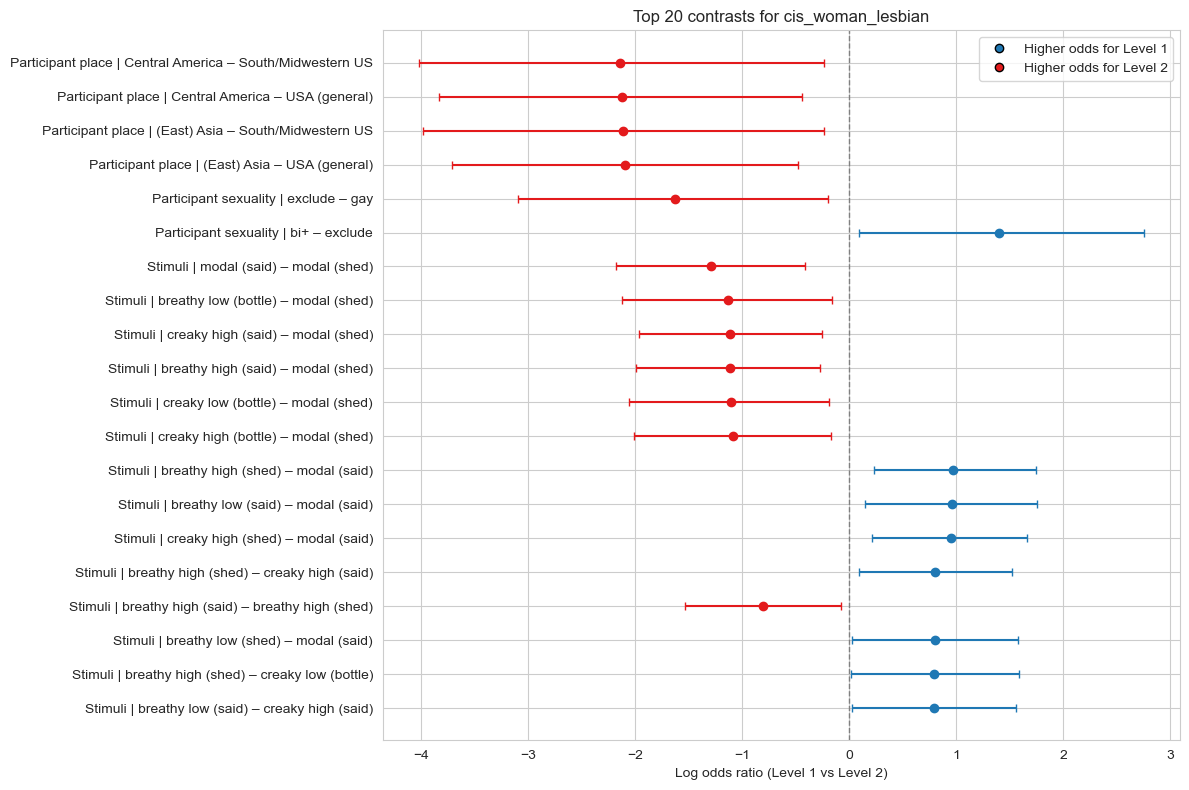

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D  # <-- needed for legend

df = pairs_sig.copy()  # already has: level1, level2, class, mean_or, hdi_or_low, hdi_or_high, or_strength, predictor

# --- Log OR & direction ---
df["log_or"]      = np.log(df["mean_or"])
df["log_or_low"]  = np.log(df["hdi_or_low"])
df["log_or_high"] = np.log(df["hdi_or_high"])

df["direction"] = np.where(df["mean_or"] > 1, "higher for L1", "higher for L2")

# Pretty predictor label
df["predictor_pretty"] = (
    df["predictor"]
    .str.replace("_", " ")
    .str.replace("stimuli clean", "Stimuli", case=True)
    .str.replace("participant gender restrictive", "Participant gender", case=True)
    .str.replace("participant sexuality normed", "Participant sexuality", case=True)
    .str.replace("participant place origin normed", "Participant place", case=True)
    .str.replace("race ses cond", "Race/educ.", case=True)
)

# Final y-axis label: "Predictor | level1 – level2"
df["contrast_label"] = (
    df["predictor_pretty"] + " | " + df["level1"] + " – " + df["level2"]
)

# --- Select a class & top N by effect strength ---
target_class = "cis_woman_lesbian"
top_n = 20

sub = (
    df[df["class"] == target_class]
    .copy()
    .sort_values("or_strength", ascending=False)
    .head(top_n)
    .iloc[::-1]                 # reverse so strongest at top of plot
)

# --- Plot ---
plt.figure(figsize=(12, 8))

palette = {
    "higher for L1": "#1f78b4",  # blue
    "higher for L2": "#e31a1c",  # red
}

y_positions = np.arange(len(sub))

log_or     = sub["log_or"].values
log_or_lo  = sub["log_or_low"].values
log_or_hi  = sub["log_or_high"].values
err_low    = log_or - log_or_lo
err_high   = log_or_hi - log_or

for i, row in sub.iterrows():
    idx = sub.index.get_loc(i)
    d   = row["direction"]
    plt.errorbar(
        row["log_or"],
        idx,
        xerr=[[err_low[idx]], [err_high[idx]]],
        fmt="o",
        color=palette[d],
        ecolor=palette[d],
        capsize=3,
    )

# Reference line at log(OR) = 0 (no difference)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)

# Legend: blue vs red meaning
plt.legend(
    handles=[
        Line2D([0], [0], marker='o', color='none',
               markerfacecolor=palette['higher for L1'],
               label='Higher odds for Level 1'),
        Line2D([0], [0], marker='o', color='none',
               markerfacecolor=palette['higher for L2'],
               label='Higher odds for Level 2'),
    ],
    loc="upper right"
)

plt.yticks(y_positions, sub["contrast_label"])
plt.xlabel("Log odds ratio (Level 1 vs Level 2)")
plt.title(f"Top {top_n} contrasts for {target_class}")
plt.tight_layout()
plt.show()